# 3DSLA Notebook
Plots self-limiting assembly curves

In [1]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
import fnmatch
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

def find_midlayer_pt_3d(mesh_dir,simdir,dumpname,ptx,pty,frame):
    ### load mesh data
    xpos = np.loadtxt("{}/xpos".format(mesh_dir))
    ypos = np.loadtxt("{}/ypos".format(mesh_dir))
    zpos = np.loadtxt("{}/zpos".format(mesh_dir))
    # nlist = np.loadtxt("{}/nlist".format(mesh_dir),dtype=int)
    # indexlist = np.loadtxt("{}/indexlist".format(mesh_dir),dtype=int)
    # npairs = np.loadtxt("{}/npairs".format(mesh_dir),dtype=int)
    # ipairs = np.loadtxt("{}/ipairs".format(mesh_dir),dtype=int)
    atomids = np.loadtxt("{}/atomids".format(mesh_dir),dtype=int)
    # atomtypes = np.loadtxt("{}/atomtypes".format(mesh_dir),dtype=int)
    # bidlist = np.loadtxt("{}/bidlist".format(mesh_dir),dtype=int)
    # btypelist = np.loadtxt("{}/btypelist".format(mesh_dir),dtype=int)

    # wx = np.max(xpos)-np.min(xpos)
    # wy = np.max(ypos)-np.min(ypos)
    natoms = np.size(atomids)
    
    ### read dump file
    result = ReadSim(simdir)
    if (frame==0) or (frame==-1):
        result.read_dump(dumpname=dumpname,readall=False)
    else:
        result.read_dump(dumpname=dumpname,readall=True)
#     result.read_dump(dumpname=dumpname,auto_labels="yes",gz=True)

    ### locate atom nearest to ptx,pty in flat mesh
    dist2 = (xpos-ptx)**2+(ypos-pty)**2
    top = zpos>0
    bot = zpos<0
    iclosest_top = np.argmin(dist2[top])
    iclosest_bot = np.argmin(dist2[bot])
    idtop = atomids[top][iclosest_top]
    idbot = atomids[bot][iclosest_bot]

    ### calculate mid-layer points

    tops = result.dump_id[frame]%natoms == (idtop+1)%natoms
    bots = result.dump_id[frame]%natoms == (idbot+1)%natoms

    dx = result.dump_x[frame][tops]-result.dump_x[frame][bots]
    dy = result.dump_y[frame][tops]-result.dump_y[frame][bots]
    dz = result.dump_z[frame][tops]-result.dump_z[frame][bots]
    rmx = result.dump_x[frame][bots] + 0.5 * dx
    rmy = result.dump_y[frame][bots] + 0.5 * dy
    rmz = result.dump_z[frame][bots] + 0.5 * dz
    dists = np.sqrt(np.diff(rmx)**2 + np.diff(rmy)**2 + np.diff(rmz)**2)

    return (rmx,rmy,rmz,dists)

def latest_traj(files):
    # collect trajectory files
    trajectories = []
    for f in files:
        if f[:10] == "trajectory":
            trajectories.append(f)

    # find latest trajectory file
    tlast = 0
    restart = 0
    for i in np.arange(len(trajectories)):
        traj = trajectories[i]
        p = traj.index(".")
        n = int(traj[10:p])
        if n > restart:
            tlast = i
            restart = n
    dumpname = trajectories[tlast]
    return dumpname

def sconformal(h):
    return (2-2*np.sqrt(h**2+1))/h + np.arcsinh(h)

In [25]:
np.sqrt(1/10)

0.31622776601683794

# Design "A"

Targetting $\eta = 0.1 $

In [2]:
# a.0

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 4.434
r0 = 54.053
t = 5.408
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima
    # filter out when plotting
    
# cylinders
khsla_a_0 = np.array([0.066, 0.067, 0.068, 0.069, 0.07 , 0.072, 0.074, 0.076, 0.078,
       0.08 , 0.082, 0.084, 0.086, 0.088, 0.09 , 0.092, 0.094, 0.096,
       0.098, 0.1  , 0.11 , 0.12 , 0.13 , 0.14 , 0.15 , 0.16 , 0.17 ,
       0.18 , 0.19 , 0.2  , 0.22 , 0.24 , 0.26 , 0.28 , 0.3  , 0.32 ,
       0.34 , 0.36 , 0.38 , 0.4  , 0.5  , 0.6  , 0.7  , 0.8  , 0.9  ,
       1.   , 1.1  , 1.2  , 1.3  , 1.4  , 1.5  , 1.6  , 1.7  , 1.8  ,
       1.9  , 2.   ])
eflat_a_0 = np.array([0.192356354829038, 0.195270845042487, 0.19818533525061, 0.20109982545882, 
                      0.204014315672639, 0.209843296094449, 0.215672276517868, 0.221501256933055, 
                      0.227330237359455, 0.233159217778166, 0.238988198200618, 0.244817178621566, 
                      0.250646159046682, 0.256475139465497, 0.262304119887498, 0.2681331003083, 
                      0.27396208073172, 0.279791061152138, 0.285620041574415, 0.291449021996851, 
                      0.32059392410262, 0.349738826214578, 0.378883728318845, 0.408028630389928, 
                      0.43717353243245, 0.466318434471965, 0.495463336512094, 0.524608238553937, 
                      0.553753140594129, 0.582898042635016, 0.641187846715291, 0.699477650794551, 
                      0.757767454831787, 0.816057259058155, 0.874347063271027, 0.932636867489205, 
                      0.990926671711429, 1.04921647593538, 1.10750628015362, 1.16579608434737, 
                      1.45724510543366, 1.7486941265291, 2.0401431476167, 2.33159216870398, 2.62304118979132, 
                      2.9144902108785, 3.2059392319682, 3.49738825305497, 3.7888372741416, 4.08028629522803, 
                      4.37173531631442, 4.66318433740083, 4.95463335849173, 5.24608237957803, 
                      5.53753140066421, 5.82898042175029])
nsla_a_0 = np.array([60., 56., 54., 52., 50., 46., 44., 42., 40., 38., 36., 36., 34.,
       34., 32., 32., 30., 30., 30., 30., 26., 24., 22., 22., 20., 20.,
       20., 18., 18., 18., 16., 16., 14., 14., 14., 14., 12., 12., 12.,
       12., 10., 10.,  8.,  8.,  8.,  8.,  8., 8., 8., 6., 6.,  6.,
        6.,  6.,  6.,  6.])


S_a_0 = ( eadh / (2*eflat_a_0) ) * tk0
H_a_0 = nsla_a_0 * tk0

# spheres
khsla_a_45 = np.array([0.078, 0.079, 0.08 , 0.081, 0.082, 0.083, 0.084, 0.086, 0.088,
       0.09 , 0.092, 0.094, 0.096, 0.098, 0.1  , 0.11 , 0.12 , 0.13 ,
       0.14 , 0.15 , 0.16 , 0.17 , 0.18 , 0.19 , 0.2  , 0.22 , 0.24 ,
       0.26 , 0.28 , 0.3  , 0.32 , 0.34 , 0.36 , 0.38 , 0.4  , 0.5  ,
       0.6  , 0.7  , 0.8  , 0.9  , 1.   , 1.1  , 1.2  , 1.3  , 1.4  ,
       1.5  , 1.6  , 1.7  , 1.8  , 1.9  , 2.   ])
eflat_a_45 = np.array([0.227330237359455, 0.230244727569678, 0.233159217778166, 0.236073707988738, 
                       0.238988198200618, 0.241902688414699, 0.244817178621566, 0.250646159046682, 
                       0.256475139465497, 0.262304119887498, 0.2681331003083, 0.27396208073172, 
                       0.279791061152138, 0.285620041574415, 0.291449021996851, 0.32059392410262, 
                       0.349738826214578, 0.378883728318845, 0.408028630389928, 0.43717353243245, 
                       0.466318434471965, 0.495463336512094, 0.524608238553937, 0.553753140594129, 
                       0.582898042635016, 0.641187846715291, 0.699477650794551, 0.757767454831787, 
                       0.816057259058155, 0.874347063271027, 0.932636867489205, 0.990926671711429, 
                       1.04921647593538, 1.10750628015362, 1.16579608434737, 1.45724510543366, 
                       1.7486941265291, 2.0401431476167, 2.33159216870398, 2.62304118979132, 
                       2.9144902108785, 3.2059392319682, 3.49738825305497, 3.7888372741416, 
                       4.08028629522803, 4.37173531631442, 4.66318433740083, 4.95463335849173, 
                       5.24608237957803, 5.53753140066421, 5.82898042175029])
nsla_a_45 = np.array([60., 56., 54., 50., 50., 48., 46., 44., 42., 40., 38., 38., 36.,
       36., 34., 32., 28., 26., 26., 24., 22., 22., 20., 20., 20., 18.,
       18., 16., 16., 16., 16., 14., 14., 14., 14., 12., 12., 10., 10.,
       10., 10.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8., 8.])


S_a_45 = ( eadh / (2*eflat_a_45) ) * tk0
H_a_45 = nsla_a_45 * tk0


# saddles
khsla_a_m45 = np.array([0.108, 0.109, 0.11 , 0.111, 0.112, 0.113, 0.114, 0.115, 0.116,
       0.117, 0.118, 0.119, 0.12 , 0.121, 0.122, 0.123, 0.124, 0.125,
       0.13 , 0.135, 0.14 , 0.145, 0.15 , 0.155, 0.16 , 0.165, 0.17 ,
       0.175, 0.18 , 0.185, 0.19 , 0.195, 0.2  , 0.22 , 0.24 , 0.26 ,
       0.28 , 0.3  , 0.32 , 0.34 , 0.36 , 0.38 , 0.4  , 0.5  , 0.6  ,
       0.7  , 0.8  , 0.9  , 1.   , 1.1  , 1.2  , 1.3  , 1.4  , 1.6  ,
       1.8  , 2.   , 2.2  , 2.4  , 2.6  , 2.8  , 3.   ])

eflat_a_m45 = np.array([0.314764943684075, 0.317679433893282, 0.32059392410262, 0.323508414313335, 
                        0.326422904524754, 0.329337394733869, 0.332251884948236,0.335166375157176, 
                        0.3380808653741, 0.340995355580957, 0.343909845791315, 
                        0.346824336001714, 0.349738826214578, 0.352653316421761, 0.355567806633455, 
                        0.358482296845404, 0.361396787056849, 0.364311277268835, 0.378883728318845, 
                        0.393456179374185, 0.408028630389928, 0.422601081412916, 0.43717353243245, 
                        0.451745983455048, 0.466318434471965, 0.480890885490892, 0.495463336512094, 
                        0.510035787533803, 0.524608238553937, 0.539180689573274, 0.553753140594129, 
                        0.56832559161371, 0.582898042635016, 0.641187846715291, 0.699477650794551, 
                        0.757767454831787, 0.816057259058155, 0.874347063271027, 0.932636867489205, 
                        0.990926671711429, 1.04921647593538, 1.10750628015362, 1.16579608434737, 
                        1.45724510543366, 1.7486941265291, 2.0401431476167, 2.33159216870398, 
                        2.62304118979132, 2.9144902108785, 3.2059392319682, 3.49738825305497, 
                        3.7888372741416, 4.08028629522803, 4.66318433740083, 5.24608237957803, 
                        5.82898042175029, 6.41187846392233, 6.99477650609391, 7.57767454827214, 
                        8.16057259044246, 8.74347063261379])
nsla_a_m45 = np.array([60., 58., 58., 52., 52., 52., 52., 48., 48., 46., 44., 44., 44.,
       42., 42., 40., 40., 40., 38., 36., 34., 32., 30., 28., 28., 26.,
       26., 26., 24., 24., 24., 24., 22., 22., 20., 18., 18., 18., 16.,
       16., 16., 16., 14., 14., 12., 12., 10., 10., 10., 10., 8., 8.,
       8., 8., 8., 8., 8., 6., 6., 6., 6.])



S_a_m45 = ( eadh / (2*eflat_a_m45) ) * tk0
H_a_m45 = nsla_a_m45 * tk0

tk0_a_25 = tk0

In [3]:
eta

0.09870793712770251

# Design "B"

Targetting $\eta = 1$

In [4]:
# b.0

sigma = 0.4108
epsilon = 7.149441531645948e-06
t0 = 2.35
r0 = 32.893
t = 3.303
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima
    # filter out when plotting
    
# cylinders
khsla_b_0 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 ,
       1.  , 1.1 , 1.2 , 1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
eflat_b_0 = np.array([0.238240467789641, 0.262064514491804, 0.285888561198629, 0.309712607903548, 
                      0.333536654580641, 0.357360701224901, 0.381184747877283, 0.405008794524343, 
                      0.428832841174749, 0.452656887821549, 0.476480934470051, 0.524129027766728, 
                      0.571777121064617, 0.619425214318313, 0.66707330774235, 0.714721401144141, 
                      0.952961868200078, 1.19120233524867, 1.42944280229826, 1.66768326934943, 
                      1.90592373639749, 2.14416420344733, 2.38240467049279, 2.62064513754236, 
                      2.85888560458942, 3.09712607163627, 3.33536653868297, 3.57360700573174, 
                      3.81184747278107, 4.05008793983043, 4.28832840687982, 4.52656887392925, 
                      4.76480934097839])
nsla_b_0 = np.array([30., 30., 26., 26., 24., 22., 22., 20., 20., 20., 18., 18., 16.,
       16., 16., 14., 12., 12., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8., 8.,  6.,  6.,  6.])


S_b_0 = ( eadh / (2*eflat_b_0) ) * tk0
H_b_0 = nsla_b_0 * tk0



# spheres
khsla_b_45 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 ])
eflat_b_45 = np.array([0.238240467789641, 0.262064514491804, 0.285888561198629, 0.309712607903548, 
                       0.333536654580641, 0.357360701224901, 0.381184747877283, 0.405008794524343, 
                       0.428832841174749, 0.452656887821549, 0.476480934470051, 0.524129027766728, 
                       0.571777121064617, 0.619425214318313, 0.66707330774235, 0.714721401144141])
nsla_b_45 = np.array([30., 30., 28., 26., 26., 24., 22., 22., 22., 20., 20., 18., 18.,
       18., 16., 16.])


S_b_45 = ( eadh / (2*eflat_b_45) ) * tk0
H_b_45 = nsla_b_45 * tk0



# saddles
# khsla_b_m45 = np.
# eflat_b_m45 = 
# nsla_b_m45 = np.


# S_b_m45 = ( eadh / (2*eflat_b_m45) ) * tk0
# H_b_m45 = nsla_b_m45 * tk0




In [5]:
eta

0.9489435195067709

In [6]:
# b - sigma = 0.25

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 2.35
r0 = 32.893
t = 3.324
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima 
    # filter out when plotting
    
# # cylinders
khsla_b_0_0p25 = np.array([0.058, 0.06 , 0.062, 0.064, 0.066, 0.068, 0.07 , 0.072, 0.074,
       0.076, 0.078, 0.08 , 0.082, 0.084, 0.086, 0.088, 0.09 , 0.092,
       0.094, 0.096, 0.098, 0.1  , 0.11 , 0.12 , 0.13 , 0.14 , 0.15 ,
       0.16 , 0.17 , 0.18 , 0.19 , 0.2  , 0.21 , 0.22 , 0.23 , 0.24 ,
       0.25 , 0.29 , 0.3  , 0.32 , 0.34 , 0.36 , 0.38 , 0.4  , 0.42 ,
       0.44 , 0.46 , 0.48 , 0.5  , 0.52 , 0.54 , 0.56 , 0.58 , 0.6  ,
       0.65 , 0.7  , 0.75 , 0.8  , 0.85 , 0.9  , 0.95 , 1.   , 1.1  ,
       1.2  , 1.3  , 1.4  , 1.5  , 1.6  , 1.7  , 1.8  , 1.9  , 2.   ,
       2.1  , 2.2  , 2.3  , 2.4  , 2.5  , 2.6  , 2.7  , 2.8  , 2.9  ,
       3.   ])

eflat_b_0_0p25 = np.array([0.138179471631051, 0.142944280975276, 0.147709090315974, 0.152473899653392, 
                           0.157238708998434, 0.162003518334943, 0.166768327677569, 0.171533137019461, 
                           0.176297946359512, 0.18106275569832, 0.185827565038197, 0.190592374380489, 
                           0.19535718372268, 0.200121993061085, 0.204886802400215, 0.20965161174615, 
                           0.214416421086239, 0.219181230424343, 0.223946039766782, 0.228710849113168, 
                           0.23347565844496, 0.238240467789641, 0.262064514491804, 0.285888561198629, 
                           0.309712607903548, 0.333536654580641, 0.357360701224901, 0.381184747877283,
                           0.405008794524343, 0.428832841174749, 0.452656887821549, 0.476480934470051, 
                           0.500304981119145, 0.524129027766728, 0.547953074416041, 0.571777121064617, 
                           0.595601167616927, 0.690897354427825, 0.714721401144141, 0.762369494542195, 
                           0.810017587955987, 0.857665681368123, 0.905313774790149, 0.952961868200078, 
                           1.00060996160982, 1.04825805501954, 1.09590614842925, 1.14355424183896, 
                           1.19120233524867, 1.23885042865841, 1.28649852206922, 1.33414661547891, 
                           1.3817947088886, 1.42944280229826, 1.54856303582376, 1.66768326934943, 
                           1.78680350287349, 1.90592373639749, 2.02504396992145, 2.14416420344733, 
                           2.26328443697118, 2.38240467049279, 2.62064513754236, 2.85888560458942, 
                           3.09712607163627, 3.33536653868297, 3.57360700573174, 3.81184747278107, 
                           4.05008793983043, 4.28832840687982, 4.52656887392925, 4.76480934097839,
                           5.00304980802615, 5.24129027507387, 5.47953074212148, 5.717771209169, 
                           5.95601167621628, 6.19425214326347, 6.43249261031056, 6.67073307735754, 
                           6.90897354440416, 7.14721401144985])

nsla_b_0_0p25 = np.array([60., 52., 50., 48., 46., 44., 44., 42., 40., 40., 38., 38., 38.,
       36., 36., 34., 34., 34., 32., 32., 32., 30., 28., 26., 24., 22.,
       22., 20., 20., 20., 18., 18., 18., 16., 16., 16., 16., 14., 14.,
       14., 14., 14., 12., 12., 12., 12., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.])


S_b_0_0p25 = ( eadh / (2*eflat_b_0_0p25) ) * tk0
H_b_0_0p25 = nsla_b_0_0p25 * tk0



# spheres
khsla_b_45_0p25 = np.array([0.054, 0.056, 0.058, 0.06 , 0.062, 0.064, 0.066, 0.068, 0.07 ,
       0.072, 0.074, 0.076, 0.078, 0.08 , 0.082, 0.084, 0.086, 0.088,
       0.09 , 0.092, 0.094, 0.096, 0.098, 0.1  , 0.11 , 0.12 , 0.13 ,
       0.14 , 0.15 , 0.16 , 0.17 , 0.18 , 0.19 , 0.2  , 0.22 , 0.24 ,
       0.26 , 0.28 , 0.3  , 0.32 , 0.34 , 0.36 , 0.38 , 0.4  , 0.42 ,
       0.44 , 0.46 , 0.48 , 0.5  , 0.52 , 0.54 , 0.56 , 0.58 , 0.6  ,
       0.65 , 0.7  , 0.75 , 0.8  , 0.85 , 0.9  , 0.95 , 1.   , 1.05 ,
       1.1  , 1.15 , 1.2  , 1.25 , 1.3  , 1.35 , 1.4  , 1.45 , 1.5  ,
       1.6  , 1.7  , 1.8  , 1.9  , 2.   ])

eflat_b_45_0p25 = np.array([ 0.128649852950016, 0.133414662292962, 0.138179471631051, 0.142944280975276, 
                            0.147709090315974, 0.152473899653392, 0.157238708998434, 0.162003518334943, 
                            0.166768327677569, 0.171533137019461, 0.176297946359512, 0.18106275569832, 
                            0.185827565038197, 0.190592374380489, 0.19535718372268, 0.200121993061085, 
                            0.204886802400215, 0.20965161174615, 0.214416421086239, 0.219181230424343, 
                            0.223946039766782, 0.228710849113168, 0.23347565844496,
                               0.238240467789641, 0.262064514491804, 0.285888561198629, 0.309712607903548, 
                               0.333536654580641, 0.357360701224901, 0.381184747877283, 0.405008794524343, 
                               0.428832841174749, 0.452656887821549, 0.476480934470051, 0.524129027766728, 
                               0.571777121064617, 0.619425214318313, 0.66707330774235, 0.714721401144141, 
                               0.762369494542195, 0.810017587955987, 0.857665681368123, 0.905313774790149, 
                               0.952961868200078, 1.00060996160982, 1.04825805501954, 1.09590614842925, 
                               1.14355424183896, 1.19120233524867, 1.23885042865841, 1.28649852206922, 
                               1.33414661547891, 1.3817947088886, 1.42944280229826, 1.54856303582376, 
                               1.66768326934943, 1.78680350287349, 1.90592373639749, 2.02504396992145, 
                               2.14416420344733, 2.26328443697118, 2.38240467049279, 2.50152490401645, 
                               2.62064513754236, 2.73976537106592, 2.85888560458942, 2.97800583811289, 
                               3.09712607163627, 3.21624630515956, 3.33536653868297, 3.45448677220726, 
                               3.57360700573174, 3.81184747278107, 4.05008793983043, 4.28832840687982, 
                               4.52656887392925, 4.76480934097839])
nsla_b_45_0p25 = np.array([60., 58., 56., 52., 50., 48., 46., 44., 42., 40., 40., 38., 36.,
       36., 34., 34., 32., 32., 32., 30., 30., 30., 28., 28., 26., 24.,
       24., 22., 22., 20., 20., 20., 18., 18., 18., 16., 16., 16., 14.,
       14., 14., 14., 14., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       10., 10., 10., 10., 10., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  6.,  6.])


S_b_45_0p25 = ( eadh / (2*eflat_b_45_0p25) ) * tk0
H_b_45_0p25 = nsla_b_45_0p25 * tk0



# # saddles
khsla_b_m45_0p25 = np.array([0.08 , 0.082, 0.084, 0.086, 0.088, 0.09 , 0.092, 0.094, 0.096,
       0.098, 0.1  , 0.11 , 0.12 , 0.13 , 0.14 , 0.15 , 0.16 , 0.17 ,
       0.18 , 0.19 , 0.2  , 0.21 , 0.22 , 0.23 , 0.24 , 0.25 , 0.26 ,
       0.27 , 0.28 , 0.29 , 0.3  , 0.32 , 0.34 , 0.36 , 0.38 , 0.4  ,
       0.42 , 0.44 , 0.46 , 0.48 , 0.5  , 0.52 , 0.54 , 0.56 , 0.58 ,
       0.6  , 0.65 , 0.7  , 0.75 , 0.8  , 0.85 , 0.9  , 0.95 , 1.   ,
       1.05 , 1.1  , 1.15 , 1.2  , 1.25 , 1.3  , 1.35 , 1.4  , 1.45 ,
       1.5  , 1.6  , 1.7  , 1.8  , 1.9  , 2.   ])
eflat_b_m45_0p25 = np.array([0.190592374380489, 0.19535718372268, 0.200121993061085, 0.204886802400215, 
                             0.20965161174615, 0.214416421086239, 0.219181230424343, 0.223946039766782, 
                             0.228710849113168, 0.23347565844496, 0.238240467789641, 0.262064514491804, 
                             0.285888561198629, 0.309712607903548, 0.333536654580641, 0.357360701224901, 
                             0.381184747877283, 0.405008794524343, 0.428832841174749, 0.452656887821549, 
                             0.476480934470051, 0.500304981119145, 0.524129027766728, 0.547953074416041, 
                             0.571777121064617, 0.595601167616927, 0.619425214318313, 0.643249261036636, 
                             0.66707330774235, 0.690897354427825, 0.714721401144141, 0.762369494542195, 
                             0.810017587955987, 0.857665681368123, 0.905313774790149, 0.952961868200078, 
                             1.00060996160982, 1.04825805501954, 1.09590614842925, 1.14355424183896, 
                             1.19120233524867, 1.23885042865841, 1.28649852206922, 1.33414661547891, 
                             1.3817947088886, 1.42944280229826, 1.54856303582376, 1.66768326934943, 
                             1.78680350287349, 1.90592373639749, 2.02504396992145, 2.14416420344733, 
                             2.26328443697118, 2.38240467049279, 2.50152490401645, 2.62064513754236, 
                             2.73976537106592, 2.85888560458942, 2.97800583811289, 3.09712607163627, 
                             3.21624630515956, 3.33536653868297, 3.45448677220726, 3.57360700573174, 
                             3.81184747278107, 4.05008793983043, 4.28832840687982, 4.52656887392925, 
                             4.76480934097839])
nsla_b_m45_0p25 = np.array([60., 56., 56., 54., 54., 52., 48., 48., 46., 44., 42., 38., 34.,
       30., 30., 28., 26., 24., 24., 22., 22., 20., 20., 20., 18., 18.,
       18., 18., 16., 16., 16., 16., 16., 14., 14., 14., 14., 14., 14.,
       12., 12., 12., 12., 12., 12., 12., 12., 10., 10., 10., 10., 10.,
       10., 10., 10.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
       8., 8., 8., 8.])





S_b_m45_0p25 = ( eadh / (2*eflat_b_m45_0p25) ) * tk0
H_b_m45_0p25 = nsla_b_m45_0p25 * tk0

tk0_b_0p25 = tk0


In [7]:
eta

0.9489435195067709

# Design "C"

Targetting $\eta = 10 $

In [8]:
# c.0

sigma = 0.6368
epsilon = 4.4305240601244645e-06
t0 = 1.2
r0 = 21.221
t = 2.127
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima
    # filter out when plotting
    
# cylinders
khsla_c_0 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 , 1.  , 1.1 , 1.2 , 1.3 ,
       1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
eflat_c_0 = np.array([0.140725557107196, 0.154798112773004, 0.168870668441728, 0.182943224107902, 
                      0.197015779751557, 0.211088335385809, 0.225160891019111, 0.239233446653093, 
                      0.25330600228797, 0.267378557921906, 0.281451113554229, 0.422176670003686, 
                      0.562902226675323, 0.703627783343433, 0.844353340011359, 0.985078896678969, 
                      1.1258044533463, 1.26653001001461, 1.40725556668018, 1.5479811233482, 1.68870668001618, 
                      1.82943223668968, 1.97015779335815, 2.1108833500202, 2.25160890668821, 2.39233446335621,
                      2.53306002002422, 2.67378557669219, 2.81451113336017])
nsla_c_0 = np.array([30., 30., 30., 30., 30., 30., 30., 30., 30., 28., 26., 20., 18.,
       16., 14., 14., 12., 12., 12., 10., 10., 10., 10., 10., 10., 10.,
       10.,  8., 8.])





S_c_0 = ( eadh / (2*eflat_c_0) ) * tk0
H_c_0 = nsla_c_0 * tk0

# spheres
khsla_c_45 = np.array([0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22, 0.24, 0.26, 0.28, 0.3 ,
       0.32, 0.34, 0.36, 0.38, 0.4 , 0.5 ])
eflat_c_45 = np.array([0.140725557107196, 0.168870668441728, 0.197015779751557, 0.225160891019111, 
                       0.25330600228797, 0.281451113554229, 0.309596224823948, 0.337741336089606, 
                       0.365886447348825, 0.394031558671423, 0.422176670003686, 0.450321781336753,
                       0.478466892673438, 0.506612004007381, 0.534757115341061, 0.562902226675323, 
                       0.703627783343433])
nsla_c_45 = np.array([30., 30., 30., 30., 26., 24., 22., 20., 20., 18., 18., 18., 18.,
       16., 16., 16., 14.])

S_c_45 = ( eadh / (2*eflat_c_45) ) * tk0
H_c_45 = nsla_c_45 * tk0

# saddles
khsla_c_m45 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.5 ,
       0.6 , 0.7 , 0.8 , 0.9 , 1.  , 1.1 , 1.2 , 1.3 , 1.4 , 1.6 , 1.8 ,
       2.  , 2.2 , 2.4 , 2.6 , 2.8 , 3.  ])
eflat_c_m45 = np.array([0.140725557107196, 0.154798112773004, 0.168870668441728, 0.182943224107902, 
                        0.197015779751557, 0.211088335385809, 0.225160891019111, 0.239233446653093, 
                        0.25330600228797, 0.267378557921906, 0.281451113554229, 0.309596224823948, 
                        0.337741336089606, 0.365886447348825, 0.394031558671423, 0.422176670003686, 
                        0.450321781336753, 0.478466892673438, 0.506612004007381, 0.534757115341061, 
                        0.562902226675323, 0.703627783343433, 0.844353340011359, 0.985078896678969, 
                        1.1258044533463, 1.26653001001461, 1.40725556668018, 1.5479811233482, 
                        1.68870668001618, 1.82943223668968, 1.97015779335815, 2.25160890668821, 
                        2.53306002002422, 2.81451113336017, 3.09596224670221, 3.37741336003852, 
                        3.65886447337828, 3.94031558671478, 4.22176670005129])
nsla_c_m45 = np.array([30., 30., 28., 26., 26., 24., 24., 22., 22., 22., 20., 20., 20.,
       18., 18., 18., 18., 16., 16., 16., 16., 14., 12., 12., 12., 12.,
       12., 12., 10., 10., 10., 10., 10., 10., 10., 8., 8., 8., 8.])


S_c_m45 = ( eadh / (2*eflat_c_m45) ) * tk0
H_c_m45 = nsla_c_m45 * tk0




In [9]:
eta

8.74357170665111

In [10]:
# c - sigma = 0.25

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 1.2
r0 = 21.221
t = 2.174
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima 
    # filter out when plotting
    
# # cylinders
khsla_c_0_0p25 = np.array([0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.32, 0.34,
       0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56,
       0.58, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 ,
       2.  , 2.1 , 2.2 , 2.3 , 2.4 , 2.5 , 2.6 , 2.7 , 2.8 , 2.9 , 3.  ,
       3.2 , 3.4 , 3.6 , 3.8 , 4.  , 4.2 , 4.4 , 4.6 , 4.8 , 5.  ])
eflat_c_0_0p25 = np.array([0.154798112773004, 0.168870668441728, 0.182943224107902, 0.197015779751557, 
                           0.211088335385809, 0.225160891019111, 0.239233446653093, 0.25330600228797, 
                           0.267378557921906, 0.281451113554229, 0.29552366918807, 0.309596224823948, 
                           0.323668780456565, 0.337741336089606, 0.351813891672317, 0.365886447348825, 
                           0.379959003005816, 0.394031558671423, 0.408104114339125, 0.422176670003686, 
                           0.450321781336753, 0.478466892673438, 0.506612004007381, 0.534757115341061, 
                           0.562902226675323, 0.591047338009093, 0.619192449341611, 0.647337560675937, 
                           0.675482672009677, 0.703627783343433, 0.731772894677177, 0.759918006010181, 
                           0.788063117343897, 0.816208228677628, 0.844353340011359, 0.914716118344753, 
                           0.985078896678969, 1.05544167501216, 1.1258044533463, 1.19616723168046, 
                           1.26653001001461, 1.33689278834876, 1.40725556668018, 1.47761834501418, 
                           1.5479811233482, 1.61834390168221, 1.68870668001618, 1.75906945835546, 
                           1.82943223668968, 1.97015779335815, 2.1108833500202, 2.25160890668821, 
                           2.39233446335621, 2.53306002002422, 2.67378557669219, 2.81451113336017, 
                           2.95523669002808, 3.09596224670221, 3.23668780337036, 3.37741336003852, 
                           3.51813891671012, 3.65886447337828, 3.79959003004655, 3.94031558671478, 
                           4.08104114338299, 4.22176670005129, 4.50321781338794, 4.78466892672008, 
                           5.06612004005685, 5.34757115339383, 5.62902226671961, 5.91047338006751, 
                           6.19192449339218, 6.47337560672859, 6.75482672006491, 7.03627783340152])
nsla_c_0_0p25 = np.array([38., 38., 34., 32., 30., 28., 26., 26., 26., 24., 24., 22., 22.,
       22., 22., 20., 20., 20., 20., 18., 18., 18., 16., 16., 16., 16.,
       16., 14., 14., 14., 14., 14., 14., 14., 14., 12., 12., 12., 12.,
       12., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.])



S_c_0_0p25 = ( eadh / (2*eflat_c_0_0p25) ) * tk0
H_c_0_0p25 = nsla_c_0_0p25 * tk0



# spheres
khsla_c_45_0p25 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.65, 0.7 ,
       0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15, 1.2 , 1.25,
       1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
eflat_c_45_0p25 = np.array([0.140725557107196, 0.154798112773004, 0.168870668441728, 0.182943224107902, 
                            0.197015779751557, 0.211088335385809, 0.225160891019111, 0.239233446653093, 
                            0.25330600228797, 0.267378557921906, 0.281451113554229, 0.309596224823948, 
                            0.337741336089606, 0.365886447348825, 0.394031558671423, 0.422176670003686, 
                            0.450321781336753, 0.478466892673438, 0.506612004007381, 0.534757115341061, 
                            0.562902226675323, 0.591047338009093, 0.619192449341611, 0.647337560675937, 
                            0.675482672009677, 0.703627783343433, 0.731772894677177, 0.759918006010181, 
                            0.788063117343897, 0.816208228677628, 0.844353340011359, 0.914716118344753, 
                            0.985078896678969, 1.05544167501216, 1.1258044533463, 1.19616723168046, 
                            1.26653001001461, 1.33689278834876, 1.40725556668018, 1.47761834501418, 
                            1.5479811233482, 1.61834390168221, 1.68870668001618, 1.75906945835546, 
                            1.82943223668968, 1.89979501502391, 1.97015779335815, 2.04052057168618, 
                            2.1108833500202, 2.25160890668821, 2.39233446335621, 2.53306002002422, 
                            2.67378557669219, 2.81451113336017])
nsla_c_45_0p25 = np.array([28., 26., 24., 22., 20., 20., 18., 18., 18., 16., 16., 16., 14.,
       14., 14., 14., 12., 12., 12., 12., 12., 12., 12., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8., 8., 8., 8.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.])



S_c_45_0p25 = ( eadh / (2*eflat_c_45_0p25) ) * tk0
H_c_45_0p25 = nsla_c_45_0p25 * tk0



# # saddles
khsla_c_m45_0p25 = np.array([0.08, 0.09, 0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18,
       0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29,
       0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 ,
       0.52, 0.54, 0.56, 0.58, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ,
       0.95, 1.  ])
eflat_c_m45_0p25 = np.array([0.112580445775243, 0.126653001439028, 0.140725557107196, 0.154798112773004, 
                             0.168870668441728, 0.182943224107902, 0.197015779751557, 0.211088335385809, 
                             0.225160891019111, 0.239233446653093, 0.25330600228797, 0.267378557921906, 
                             0.281451113554229, 0.29552366918807, 0.309596224823948, 0.323668780456565, 
                             0.337741336089606, 0.351813891672317, 0.365886447348825, 0.379959003005816, 
                             0.394031558671423, 0.408104114339125, 0.422176670003686, 0.450321781336753, 
                             0.478466892673438, 0.506612004007381, 0.534757115341061, 0.562902226675323, 
                             0.591047338009093, 0.619192449341611, 0.647337560675937, 0.675482672009677, 
                             0.703627783343433, 0.731772894677177, 0.759918006010181, 0.788063117343897, 
                             0.816208228677628, 0.844353340011359, 0.914716118344753, 0.985078896678969, 
                             1.05544167501216, 1.1258044533463, 1.19616723168046, 1.26653001001461, 
                             1.33689278834876, 1.40725556668018])
nsla_c_m45_0p25 = np.array([30., 30., 28., 28., 24., 24., 24., 20., 20., 20., 20., 20., 20.,
       18., 18., 18., 18., 16., 16., 16., 16., 16., 16., 16., 14., 14.,
       14., 14., 14., 14., 14., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 10., 10., 10., 10., 10.])



S_c_m45_0p25 = ( eadh / (2*eflat_c_m45_0p25) ) * tk0
H_c_m45_0p25 = nsla_c_m45_0p25 * tk0



tk0_c_0p25 = tk0


# Design "D"

Targetting $\eta = 20 $

In [11]:
# d - sigma = 0.25

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 0.8
r0 = 21.221
t = 1.774
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima 
    # filter out when plotting
    
# # cylinders
# khsla_b_0 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
#        0.22, 0.24, 0.26, 0.28, 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 ,
#        1.  , 1.1 , 1.2 , 1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
# eflat_b_0 = np.array([0.238240467789641, 0.262064514491804, 0.285888561198629, 0.309712607903548, 
#                       0.333536654580641, 0.357360701224901, 0.381184747877283, 0.405008794524343, 
#                       0.428832841174749, 0.452656887821549, 0.476480934470051, 0.524129027766728, 
#                       0.571777121064617, 0.619425214318313, 0.66707330774235, 0.714721401144141, 
#                       0.952961868200078, 1.19120233524867, 1.42944280229826, 1.66768326934943, 
#                       1.90592373639749, 2.14416420344733, 2.38240467049279, 2.62064513754236, 
#                       2.85888560458942, 3.09712607163627, 3.33536653868297, 3.57360700573174, 
#                       3.81184747278107, 4.05008793983043, 4.28832840687982, 4.52656887392925, 
#                       4.76480934097839])
# nsla_b_0 = np.array([30., 30., 26., 26., 24., 22., 22., 20., 20., 20., 18., 18., 16.,
#        16., 16., 14., 12., 12., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,
#         8.,  8.,  8., 8.,  6.,  6.,  6.])


# S_b_0 = ( eadh / (2*eflat_b_0) ) * tk0
# H_b_0 = nsla_b_0 * tk0



# spheres
khsla_d_45_0p25 = np.array([0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25, 0.26,
       0.27, 0.28, 0.29, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44,
       0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.65, 0.7 , 0.75,
       0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15, 1.2 , 1.25, 1.3 ,
       1.35, 1.4 , 1.45, 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
eflat_d_45_0p25 = np.array([0.101670961427106, 0.108025396491872, 0.114379831556759, 0.120734266621863, 
                            0.127088701686631, 0.133443136751622, 0.13979757181653, 0.146152006881242, 
                            0.152506441921969, 0.158860877003165, 0.165215312081901, 0.171569747160744, 
                            0.177924182241263, 0.184278617321232, 0.190633052403951, 0.203341922560685, 
                            0.216050792722193, 0.228759662881613, 0.241468533040326, 0.254177403200408, 
                            0.266886273360187, 0.279595143520388, 0.292304013680416, 0.305012883840467, 
                            0.317721754000216, 0.330430624160241, 0.343139494320234, 0.355848364480254, 
                            0.368557234640261, 0.381266104800271, 0.413038280200304, 0.44481045560072, 
                            0.476582631000349, 0.508354806400825, 0.540126981800865, 0.571899157200915, 
                            0.603671332600982, 0.635443508000476, 0.667215683401068, 0.698987858801118, 
                            0.730760034201161, 0.76253220960121, 0.794304385001256, 0.826076560401298, 
                            0.857848735801361, 0.889620911201399, 0.921393086601439, 0.953165262001471, 
                            1.01670961280157, 1.08025396360162, 1.14379831440172, 1.20734266520179, 
                            1.27088701600187])
nsla_d_45_0p25 = np.array([30., 28., 26., 26., 24., 24., 22., 22., 22., 22., 22., 20., 18.,
       18., 18., 16., 16., 16., 14., 14., 14., 14., 14., 14., 14., 14.,
       12., 12., 12., 12., 12., 12., 12., 10., 10., 10., 10., 10., 10.,
       10., 10., 10.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.])


S_d_45_0p25 = ( eadh / (2*eflat_d_45_0p25) ) * tk0
H_d_45_0p25 = nsla_d_45_0p25 * tk0



# # saddles
khsla_d_m45_0p25 = np.array([0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27,
       0.28, 0.29, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46,
       0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.65, 0.7 , 0.75, 0.8 ,
       0.85, 0.9 , 0.95, 1.  ])
eflat_d_m45_0p25 = np.array([0.108025396491872, 0.114379831556759, 0.120734266621863, 0.127088701686631, 
                             0.133443136751622, 0.13979757181653, 0.146152006881242, 0.152506441921969, 
                             0.158860877003165, 0.165215312081901, 0.171569747160744, 0.177924182241263, 
                             0.184278617321232, 0.190633052403951, 0.203341922560685, 0.216050792722193, 
                             0.228759662881613, 0.241468533040326, 0.254177403200408, 0.266886273360187, 
                             0.279595143520388, 0.292304013680416, 0.305012883840467, 0.317721754000216, 
                             0.330430624160241, 0.343139494320234, 0.355848364480254, 0.368557234640261, 
                             0.381266104800271, 0.413038280200304, 0.44481045560072, 0.476582631000349, 
                             0.508354806400825, 0.540126981800865, 0.571899157200915, 0.603671332600982, 
                             0.635443508000476])
nsla_d_m45_0p25 = np.array([26., 26., 24., 24., 24., 24., 24., 24., 24., 22., 22., 22., 22.,
       22., 22., 22., 22., 20., 18., 18., 18., 18., 18., 18., 18., 18.,
       18., 18., 18., 16., 16., 16., 16., 16., 16., 16., 16.])


S_d_m45_0p25 = ( eadh / (2*eflat_d_m45_0p25) ) * tk0
H_d_m45_0p25 = nsla_d_m45_0p25 * tk0



tk0_d_0p25 = tk0


In [12]:
eta

19.673036339964995

# Design "E"

Targetting $\eta = 35 $

In [87]:
# e - sigma = 0.25

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 0.6
r0 = 21.221
t = 1.574
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima 
    # filter out when plotting
    
# # cylinders
khsla_e_0_0p25 = np.array([0.3 , 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 ,
       0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.65,
       0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15, 1.2 ,
       1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  , 2.1 , 2.2 , 2.3 ,
       2.4 , 2.5 , 2.6 , 2.7 , 2.8 , 2.9 , 3.  , 3.1 , 3.2 , 3.3 , 3.4 ,
       3.5 , 3.6 , 3.7 , 3.8 , 3.9 , 4.  , 4.1 , 4.2 , 4.3 , 4.4 , 4.5 ,
       4.6 , 4.7 , 4.8 , 4.9 , 5.  ])
eflat_e_0_0p25 = np.array([0.108070965917124, 0.111673331446839, 0.115275696977263, 0.118878062508074, 
                           0.122480428038306, 0.126082793568889, 0.129685159099316, 0.133287524629851, 
                           0.136889890160388, 0.140492255690926, 0.144094621221453, 0.151299352282656, 
                           0.158504083343582, 0.165708814404788, 0.172913545465843, 0.180118276526905, 
                           0.18732300758799, 0.194527738649065, 0.201732469710141, 0.208937200771234, 
                           0.216141931832308, 0.234153759485015, 0.252165587137699, 0.270177414790398, 
                           0.28818924244311, 0.30620107009581, 0.32421289774851, 0.342224725401197, 
                           0.360236553053888, 0.37824838070658, 0.396260208359276, 0.414272036011977, 
                           0.432283863664669, 0.468307518970069, 0.504331174275451, 0.54035482958082, 
                           0.57637848488619, 0.612402140191568, 0.648425795496937, 0.684449450802327, 
                           0.720473106107695, 0.756496761413058, 0.792520416717723, 0.828544072023049, 
                           0.864567727328364, 0.900591382633688, 0.936615037939028, 0.972638693244364, 
                           1.00866234854969, 1.04468600385502, 1.08070965916037, 1.11673331446569, 
                           1.15275696977104, 1.18878062507638, 1.22480428038174, 1.2608279356871, 
                           1.29685159099245, 1.3328752462978, 1.36889890160315, 1.40492255690972, 
                           1.44094621221508, 1.47696986752047, 1.51299352282456, 1.54901717812988, 
                           1.58504083343667, 1.62106448874205, 1.65708814404595, 1.69311179935134, 
                           1.72913545465667, 1.76515910996198, 1.80118276526729])
nsla_e_0_0p25 = np.array([60., 56., 54., 52., 50., 50., 48., 46., 46., 46., 44., 42., 40.,
       38., 36., 36., 36., 34., 34., 32., 32., 30., 28., 28., 26., 26.,
       24., 24., 24., 24., 22., 22., 22., 20., 20., 20., 18., 18., 18.,
       18., 18., 16., 16., 16., 16., 16., 16., 14., 14., 14., 14., 14.,
       14., 14., 14., 14., 14., 14., 14., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12.])



S_e_0_0p25 = ( eadh / (2*eflat_e_0_0p25) ) * tk0
H_e_0_0p25 = nsla_e_0_0p25 * tk0



# spheres
khsla_e_45_0p25 = np.array([0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33, 0.34,
       0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 ,
       0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64, 0.66, 0.68, 0.7 , 0.72,
       0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86, 0.88, 0.9 , 0.92, 0.94,
       0.96, 0.98, 1.  , 1.05, 1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 ,
       1.45, 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
eflat_e_45_0p25 = np.array([0.086456772733516, 0.090059138263712, 0.0936615037951433, 0.0972638693247868, 
                            0.100866234857745, 0.104468600386743, 0.108070965917124, 0.111673331446839, 
                            0.115275696977263, 0.118878062508074, 0.122480428038306, 0.126082793568889, 
                            0.129685159099316, 0.133287524629851, 0.136889890160388, 0.140492255690926, 
                            0.144094621221453, 0.151299352282656, 0.158504083343582, 0.165708814404788, 
                            0.172913545465843, 0.180118276526905, 0.18732300758799, 0.194527738649065, 
                            0.201732469710141, 0.208937200771234, 0.216141931832308, 0.223346662893397, 
                            0.230551393954478, 0.23775612501555, 0.244960856076622, 0.252165587137699, 
                            0.259370318198775, 0.266575049259858, 0.273779780320941, 0.280984511382028, 
                            0.28818924244311, 0.295393973504193, 0.302598704565274, 0.309803435626349, 
                            0.317008166687427, 0.32421289774851, 0.331417628809585, 0.338622359870662, 
                            0.345827090931734, 0.35303182199281, 0.360236553053888, 0.37824838070658, 
                            0.396260208359276, 0.414272036011977, 0.432283863664669, 0.45029569131737, 
                            0.468307518970069, 0.486319346622765, 0.504331174275451, 0.522343001928137, 
                            0.54035482958082, 0.57637848488619, 0.612402140191568, 0.648425795496937, 
                            0.684449450802327, 0.720473106107695])
nsla_e_45_0p25 = np.array([26., 26., 26., 26., 24., 24., 22., 20., 20., 20., 20., 20., 18.,
       18., 18., 18., 18., 18., 18., 18., 18., 18., 16., 16., 14., 14.,
       14., 14., 14., 14., 14., 14., 14., 14., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 8., 8., 8.])




S_e_45_0p25 = ( eadh / (2*eflat_e_45_0p25) ) * tk0
H_e_45_0p25 = nsla_e_45_0p25 * tk0



# # saddles
khsla_e_m45_0p25 = np.array([0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.32, 0.34, 0.36,
       0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 ,
       1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.7 ,
       1.8 , 1.9 , 2.  , 2.1 , 2.2 , 2.3 , 2.4 , 2.5 , 2.6 , 2.7 , 2.8 ,
       2.9 , 3.  ])
eflat_e_m45_0p25 = np.array([0.082854407203924, 0.086456772733516, 0.090059138263712, 0.0936615037951433,
                             0.0972638693247868, 0.100866234857745, 0.104468600386743, 0.108070965917124, 
                             0.115275696977263, 0.122480428038306, 0.129685159099316, 0.136889890160388, 
                             0.144094621221453, 0.151299352282656, 0.158504083343582, 0.165708814404788, 
                             0.172913545465843, 0.180118276526905, 0.18732300758799, 0.194527738649065, 
                             0.201732469710141, 0.208937200771234, 0.216141931832308, 0.234153759485015, 
                             0.252165587137699, 0.270177414790398, 0.28818924244311, 0.30620107009581, 
                             0.32421289774851, 0.342224725401197, 0.360236553053888, 0.37824838070658, 
                             0.396260208359276, 0.414272036011977, 0.432283863664669, 0.45029569131737, 
                             0.468307518970069, 0.486319346622765, 0.504331174275451, 0.522343001928137,
                             0.54035482958082, 0.558366657233514, 0.57637848488619, 0.612402140191568, 
                             0.648425795496937, 0.684449450802327, 0.720473106107695, 0.756496761413058,
                             0.792520416717723, 0.828544072023049, 0.864567727328364, 0.900591382633688, 
                             0.936615037939028, 0.972638693244364, 1.00866234854969, 1.04468600385502, 
                             1.08070965916037])
nsla_e_m45_0p25 = np.array([28., 28., 28., 26., 26., 26., 26., 26., 26., 24., 24., 24., 24.,
       24., 24., 24., 22., 22., 22., 22., 22., 22., 22., 20., 20., 20.,
       20., 20., 18., 18., 18., 18., 18., 18., 18., 18., 16., 16., 16.,
       16., 16., 16., 16., 16., 16., 16., 14., 14., 14., 14., 14., 14.,
       14., 14., 14., 14., 14.])

S_e_m45_0p25 = ( eadh / (2*eflat_e_m45_0p25) ) * tk0
H_e_m45_0p25 = nsla_e_m45_0p25 * tk0




tk0_e_0p25 = tk0


In [15]:
eta

34.97428682660444

# Design "F"

Targetting $\eta = 70 $

In [16]:
# f.0

sigma = 0.8999
epsilon = 3.0055178781968955e-06
t0 = 0.6
r0 = 15.015
t = 1.497
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima
    # filter out when plotting
    
# # cylinders
# khsla_d_0 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
#        0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 , 1.  , 1.1 , 1.2 , 1.3 ,
#        1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
# eflat_d_0 = np.array([0.140725557107196, 0.154798112773004, 0.168870668441728, 0.182943224107902, 
#                       0.197015779751557, 0.211088335385809, 0.225160891019111, 0.239233446653093, 
#                       0.25330600228797, 0.267378557921906, 0.281451113554229, 0.422176670003686, 
#                       0.562902226675323, 0.703627783343433, 0.844353340011359, 0.985078896678969, 
#                       1.1258044533463, 1.26653001001461, 1.40725556668018, 1.5479811233482, 1.68870668001618, 
#                       1.82943223668968, 1.97015779335815, 2.1108833500202, 2.25160890668821, 2.39233446335621,
#                       2.53306002002422, 2.67378557669219, 2.81451113336017])
# nsla_d_0 = np.array([30., 30., 30., 30., 30., 30., 30., 30., 30., 28., 26., 20., 18.,
#        16., 14., 14., 12., 12., 12., 10., 10., 10., 10., 10., 10., 10.,
#        10.,  8., 8.])

# S_d_0 = ( eadh / (2*eflat_d_0) ) * tk0
# H_d_0 = nsla_d_0 * tk0



# # spheres
# khsla_d_45 = np.array([0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22, 0.24, 0.26, 0.28, 0.3 ,
#        0.32, 0.34, 0.36, 0.38, 0.4 , 0.5 ])
# eflat_d_45 = np.array([0.140725557107196, 0.168870668441728, 0.197015779751557, 0.225160891019111, 
#                        0.25330600228797, 0.281451113554229, 0.309596224823948, 0.337741336089606, 
#                        0.365886447348825, 0.394031558671423, 0.422176670003686, 0.450321781336753,
#                        0.478466892673438, 0.506612004007381, 0.534757115341061, 0.562902226675323, 
#                        0.703627783343433])
# nsla_d_45 = np.array([30., 30., 30., 30., 26., 24., 22., 20., 20., 18., 18., 18., 18.,
#        16., 16., 16., 14.])

# S_d_45 = ( eadh / (2*eflat_d_45) ) * tk0
# H_d_45 = nsla_d_45 * tk0

# # saddles
# khsla_d_m45 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
#        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.5 ,
#        0.6 , 0.7 , 0.8 , 0.9 , 1.  , 1.1 , 1.2 , 1.3 , 1.4 , 1.6 , 1.8 ,
#        2.  , 2.2 , 2.4 , 2.6 , 2.8 , 3.  ])
# eflat_d_m45 = np.array([0.140725557107196, 0.154798112773004, 0.168870668441728, 0.182943224107902, 
#                         0.197015779751557, 0.211088335385809, 0.225160891019111, 0.239233446653093, 
#                         0.25330600228797, 0.267378557921906, 0.281451113554229, 0.309596224823948, 
#                         0.337741336089606, 0.365886447348825, 0.394031558671423, 0.422176670003686, 
#                         0.450321781336753, 0.478466892673438, 0.506612004007381, 0.534757115341061, 
#                         0.562902226675323, 0.703627783343433, 0.844353340011359, 0.985078896678969, 
#                         1.1258044533463, 1.26653001001461, 1.40725556668018, 1.5479811233482, 
#                         1.68870668001618, 1.82943223668968, 1.97015779335815, 2.25160890668821, 
#                         2.53306002002422, 2.81451113336017, 3.09596224670221, 3.37741336003852, 
#                         3.65886447337828, 3.94031558671478, 4.22176670005129])
# nsla_d_m45 = np.array([30., 30., 28., 26., 26., 24., 24., 22., 22., 22., 20., 20., 20.,
#        18., 18., 18., 18., 16., 16., 16., 16., 14., 12., 12., 12., 12.,
#        12., 12., 10., 10., 10., 10., 10., 10., 10., 8., 8., 8., 8.])


# S_d_m45 = ( eadh / (2*eflat_d_m45) ) * tk0
# H_d_m45 = nsla_d_m45 * tk0




In [17]:
eta

69.86020972034957

In [18]:
# f - sigma = 0.25

sigma = 0.25
epsilon = 1.4464536457630208e-05
t0 = 0.6
r0 = 15.015
t = 1.574
tk0 = t/r0
wx = 30
wy = 30
a = np.sqrt(1/10)
eta = 0.007 * wx**4 / ((t0*r0)**2)
eadh = 1

# note: following lists include maximum stack size tried if it has lowest energy
    # these are not necessarily energy minima 
    # filter out when plotting
    
# # cylinders
# khsla_b_0 = np.array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
#        0.22, 0.24, 0.26, 0.28, 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 ,
#        1.  , 1.1 , 1.2 , 1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 , 2.  ])
# eflat_b_0 = np.array([0.238240467789641, 0.262064514491804, 0.285888561198629, 0.309712607903548, 
#                       0.333536654580641, 0.357360701224901, 0.381184747877283, 0.405008794524343, 
#                       0.428832841174749, 0.452656887821549, 0.476480934470051, 0.524129027766728, 
#                       0.571777121064617, 0.619425214318313, 0.66707330774235, 0.714721401144141, 
#                       0.952961868200078, 1.19120233524867, 1.42944280229826, 1.66768326934943, 
#                       1.90592373639749, 2.14416420344733, 2.38240467049279, 2.62064513754236, 
#                       2.85888560458942, 3.09712607163627, 3.33536653868297, 3.57360700573174, 
#                       3.81184747278107, 4.05008793983043, 4.28832840687982, 4.52656887392925, 
#                       4.76480934097839])
# nsla_b_0 = np.array([30., 30., 26., 26., 24., 22., 22., 20., 20., 20., 18., 18., 16.,
#        16., 16., 14., 12., 12., 10., 10., 10.,  8.,  8.,  8.,  8.,  8.,
#         8.,  8.,  8., 8.,  6.,  6.,  6.])


# S_b_0 = ( eadh / (2*eflat_b_0) ) * tk0
# H_b_0 = nsla_b_0 * tk0



# spheres
khsla_f_45_0p25 = np.
eflat_f_45_0p25 = np.
nsla_f_45_0p25 = np.


S_f_45_0p25 = ( eadh / (2*eflat_f_45_0p25) ) * tk0
H_f_45_0p25 = nsla_f_45_0p25 * tk0



# # saddles
# khsla_b_m45 = np.
# eflat_b_m45 = 
# nsla_b_m45 = np.


# S_b_m45 = ( eadh / (2*eflat_b_m45) ) * tk0
# H_b_m45 = nsla_b_m45 * tk0

tk0_f_0p25 = tk0


SyntaxError: invalid syntax (1052717681.py, line 43)

# Plots

## sigma = 0.25

In [14]:
cyl_colors = plt.cm.Greens(np.array([0.99,0.85,0.7,0.55,0.4])) 
sad_colors = plt.cm.Oranges(np.array([0.99,0.85,0.7,0.55,0.4]))
sph_colors = plt.cm.Purples(np.array([0.99,0.8,0.7,0.6,0.4,0.2]))

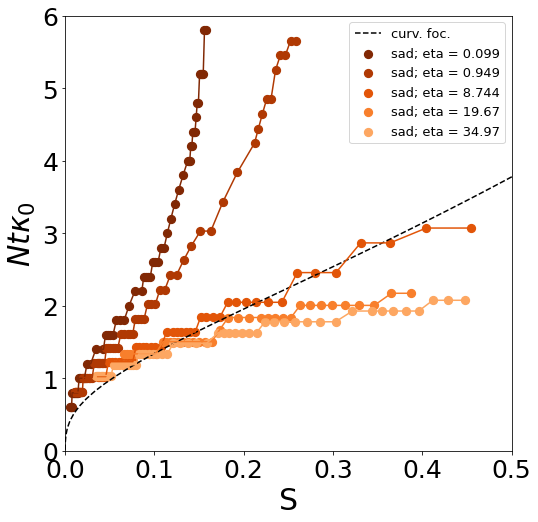

In [19]:
nmax = 59  # maximum stack size that counts as "self-limiting"

mask_a_0 = (nsla_a_0 <= nmax)
# mask_b_0 = (nsla_b_0 <= nmax)
# mask_c_0 = (nsla_c_0 <= nmax)
mask_b_0_0p25 = (nsla_b_0_0p25 <= nmax)
mask_c_0_0p25 = (nsla_c_0_0p25 <= nmax)
mask_e_0_0p25 = (nsla_e_0_0p25 <= nmax)


mask_a_45 = (nsla_a_45 <= nmax)
mask_b_45_0p25 = (nsla_b_45_0p25 <= nmax)
mask_c_45_0p25 = (nsla_c_45_0p25 <= nmax)
mask_d_45_0p25 = (nsla_d_45_0p25 <= nmax)
mask_e_45_0p25 = (nsla_e_45_0p25 <= nmax)

mask_a_m45 = (nsla_a_m45 <= nmax)
mask_b_m45_0p25 = (nsla_b_m45_0p25 <= nmax)
mask_c_m45_0p25 = (nsla_c_m45_0p25 <= nmax)
mask_d_m45_0p25 = (nsla_d_m45_0p25 <= nmax)
mask_e_m45_0p25 = (nsla_e_m45_0p25 <= nmax)


mask_c_m45 = (nsla_c_m45 <= nmax)


hc = np.linspace(0.01,10,100)
sc = sconformal(hc)

# fig, ax = plt.subplots(1,1,figsize = (6,8))
fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(sc,hc,"k--",label="curv. foc.")

### cylinders
# ax.plot(S_a_0[mask_a_0],H_a_0[mask_a_0],"-",color=cyl_colors[0])
# ax.scatter(S_a_0[mask_a_0],H_a_0[mask_a_0],edgecolor=cyl_colors[0],facecolor=cyl_colors[0],s=60,linewidths=1.5,label="cyl; eta = 0.099")
# ax.plot(S_b_0_0p25[mask_b_0_0p25],H_b_0_0p25[mask_b_0_0p25],"-",color=cyl_colors[1])
# ax.scatter(S_b_0_0p25[mask_b_0_0p25],H_b_0_0p25[mask_b_0_0p25],edgecolor=cyl_colors[1],facecolor=cyl_colors[1],s=60,linewidths=1.5,label="cyl; eta = 0.949")
# ax.plot(S_c_0_0p25[mask_c_0_0p25],H_c_0_0p25[mask_c_0_0p25],"-",color=cyl_colors[2])
# ax.scatter(S_c_0_0p25[mask_c_0_0p25],H_c_0_0p25[mask_c_0_0p25],edgecolor=cyl_colors[2],facecolor=cyl_colors[2],s=60,linewidths=1.5,label="cyl; eta = 8.744")

# ax.plot(S_e_0_0p25[mask_e_0_0p25],H_e_0_0p25[mask_e_0_0p25],"-",color=cyl_colors[4])
# ax.scatter(S_e_0_0p25[mask_e_0_0p25],H_e_0_0p25[mask_e_0_0p25],edgecolor=cyl_colors[4],facecolor=cyl_colors[4],s=60,linewidths=1.5,label="cyl; eta = 34.97")


# ax.plot(S_b_0[mask_b_0],H_b_0[mask_b_0],"-",color=cyl_colors[1])
# ax.scatter(S_b_0[mask_b_0],H_b_0[mask_b_0],edgecolor=cyl_colors[1],facecolor=cyl_colors[1],s=60,linewidths=1.5,label="cyl; eta = 0.949")
# ax.plot(S_c_0[mask_c_0],H_c_0[mask_c_0],"-",color=cyl_colors[2])
# ax.scatter(S_c_0[mask_c_0],H_c_0[mask_c_0],edgecolor=cyl_colors[2],facecolor=cyl_colors[2],s=60,linewidths=1.5,label="cyl; eta = 8.744")


### spheres
# ax.plot(S_a_45[mask_a_45],H_a_45[mask_a_45],"-",color=sph_colors[0])
# ax.scatter(S_a_45[mask_a_45],H_a_45[mask_a_45],edgecolor=sph_colors[0],facecolor=sph_colors[0],s=60,linewidths=1.5,label="sph; eta = 0.099")
# ax.plot(S_b_45_0p25[mask_b_45_0p25],H_b_45_0p25[mask_b_45_0p25],"-",color=sph_colors[1])
# ax.scatter(S_b_45_0p25[mask_b_45_0p25],H_b_45_0p25[mask_b_45_0p25],edgecolor=sph_colors[1],facecolor=sph_colors[1],s=60,linewidths=1.5,label="sph; eta = 0.949")
# ax.plot(S_c_45_0p25[mask_c_45_0p25],H_c_45_0p25[mask_c_45_0p25],"-",color=sph_colors[2])
# ax.scatter(S_c_45_0p25[mask_c_45_0p25],H_c_45_0p25[mask_c_45_0p25],edgecolor=sph_colors[2],facecolor=sph_colors[2],s=60,linewidths=1.5,label="sph; eta = 8.744")
# ax.plot(S_d_45_0p25[mask_d_45_0p25],H_d_45_0p25[mask_d_45_0p25],"-",color=sph_colors[3])
# ax.scatter(S_d_45_0p25[mask_d_45_0p25],H_d_45_0p25[mask_d_45_0p25],edgecolor=sph_colors[3],facecolor=sph_colors[3],s=60,linewidths=1.5,label="sph; eta = 19.67")
# ax.plot(S_e_45_0p25[mask_e_45_0p25],H_e_45_0p25[mask_e_45_0p25],"-",color=sph_colors[4])
# ax.scatter(S_e_45_0p25[mask_e_45_0p25],H_e_45_0p25[mask_e_45_0p25],edgecolor=sph_colors[4],facecolor=sph_colors[4],s=60,linewidths=1.5,label="sph; eta = 34.97")


### saddles
ax.plot(S_a_m45[mask_a_m45],H_a_m45[mask_a_m45],"-",color=sad_colors[0])
ax.scatter(S_a_m45[mask_a_m45],H_a_m45[mask_a_m45],edgecolor=sad_colors[0],facecolor=sad_colors[0],s=60,linewidths=1.5,label="sad; eta = 0.099")
ax.plot(S_b_m45_0p25[mask_b_m45_0p25],H_b_m45_0p25[mask_b_m45_0p25],"-",color=sad_colors[1])
ax.scatter(S_b_m45_0p25[mask_b_m45_0p25],H_b_m45_0p25[mask_b_m45_0p25],edgecolor=sad_colors[1],facecolor=sad_colors[1],s=60,linewidths=1.5,label="sad; eta = 0.949")
ax.plot(S_c_m45_0p25[mask_c_m45_0p25],H_c_m45_0p25[mask_c_m45_0p25],"-",color=sad_colors[2])
ax.scatter(S_c_m45_0p25[mask_c_m45_0p25],H_c_m45_0p25[mask_c_m45_0p25],edgecolor=sad_colors[2],facecolor=sad_colors[2],s=60,linewidths=1.5,label="sad; eta = 8.744")
ax.plot(S_d_m45_0p25[mask_d_m45_0p25],H_d_m45_0p25[mask_d_m45_0p25],"-",color=sad_colors[3])
ax.scatter(S_d_m45_0p25[mask_d_m45_0p25],H_d_m45_0p25[mask_d_m45_0p25],edgecolor=sad_colors[3],facecolor=sad_colors[3],s=60,linewidths=1.5,label="sad; eta = 19.67")
ax.plot(S_e_m45_0p25[mask_e_m45_0p25],H_e_m45_0p25[mask_e_m45_0p25],"-",color=sad_colors[4])
ax.scatter(S_e_m45_0p25[mask_e_m45_0p25],H_e_m45_0p25[mask_e_m45_0p25],edgecolor=sad_colors[4],facecolor=sad_colors[4],s=60,linewidths=1.5,label="sad; eta = 34.97")


# ax.plot(S_c_m45[mask_c_m45],H_c_m45[mask_c_m45],"-",color=sad_colors[2])
# ax.scatter(S_c_m45[mask_c_m45],H_c_m45[mask_c_m45],edgecolor=sad_colors[2],facecolor=sad_colors[2],s=60,linewidths=1.5,label="sad; eta = 8.744")


# ax.set_ylabel("H_min",fontsize=20)
ax.set_ylabel("$N t \kappa_0$",fontsize=30)
ax.set_xlabel("S",fontsize=30)
ax.legend(fontsize=13)
# ax.set_xlim(0,0.8)
ax.set_xlim(0,0.5)
ax.set_ylim(0,6)
ax.tick_params(labelsize=25)
# ax.set_xlim(0,0.2)
# ax.set_ylim(0,3)

In [36]:
# export self-limiting data to .txt files

# saddles
Slist_m45 = [S_a_m45[mask_a_m45].tolist(),
    S_b_m45_0p25[mask_b_m45_0p25].tolist(),
    S_c_m45_0p25[mask_c_m45_0p25].tolist(),
    S_d_m45_0p25[mask_d_m45_0p25].tolist(),
    S_e_m45_0p25[mask_e_m45_0p25].tolist(),
]

Hlist_m45 = [H_a_m45[mask_a_m45].tolist(),
    H_b_m45_0p25[mask_b_m45_0p25].tolist(),
    H_c_m45_0p25[mask_c_m45_0p25].tolist(),
    H_d_m45_0p25[mask_d_m45_0p25].tolist(),
    H_e_m45_0p25[mask_e_m45_0p25].tolist(),
]

# spheres
Slist_45 = [S_a_45[mask_a_45].tolist(),
    S_b_45_0p25[mask_b_45_0p25].tolist(),
    S_c_45_0p25[mask_c_45_0p25].tolist(),
    S_d_45_0p25[mask_d_45_0p25].tolist(),
    S_e_45_0p25[mask_e_45_0p25].tolist(),
]

Hlist_45 = [H_a_45[mask_a_45].tolist(),
    H_b_45_0p25[mask_b_45_0p25].tolist(),
    H_c_45_0p25[mask_c_45_0p25].tolist(),
    H_d_45_0p25[mask_d_45_0p25].tolist(),
    H_e_45_0p25[mask_e_45_0p25].tolist(),
]

# cylinders
Slist_0 = [S_a_0[mask_a_0].tolist(),
    S_b_0_0p25[mask_b_0_0p25].tolist(),
    S_c_0_0p25[mask_c_0_0p25].tolist(),
    np.zeros(10).tolist(),    # place holder; don't have data
    S_e_0_0p25[mask_e_0_0p25].tolist(),
]

Hlist_0 = [H_a_0[mask_a_0].tolist(),
    H_b_0_0p25[mask_b_0_0p25].tolist(),
    H_c_0_0p25[mask_c_0_0p25].tolist(),
    np.zeros(10).tolist(),
    H_e_0_0p25[mask_e_0_0p25].tolist(),
]

txtdir = "/Users/kyle/Documents/Wolfram Mathematica/3D Curvamers/SimData"

### saddles
with open(f"{txtdir}/SLA_a_sad_0p25.txt", "w") as f:
    for i in range(len(S_a_m45[mask_a_m45])):
        f.write(f"{S_a_m45[mask_a_m45][i]} {H_a_m45[mask_a_m45][i]}\n")
        
with open(f"{txtdir}/SLA_b_sad_0p25.txt", "w") as f:
    for i in range(len(S_b_m45_0p25[mask_b_m45_0p25])):
        f.write(f"{S_b_m45_0p25[mask_b_m45_0p25][i]} {H_b_m45_0p25[mask_b_m45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_c_sad_0p25.txt", "w") as f:
    for i in range(len(S_c_m45_0p25[mask_c_m45_0p25])):
        f.write(f"{S_c_m45_0p25[mask_c_m45_0p25][i]} {H_c_m45_0p25[mask_c_m45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_d_sad_0p25.txt", "w") as f:
    for i in range(len(S_d_m45_0p25[mask_d_m45_0p25])):
        f.write(f"{S_d_m45_0p25[mask_d_m45_0p25][i]} {H_d_m45_0p25[mask_d_m45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_e_sad_0p25.txt", "w") as f:
    for i in range(len(S_e_m45_0p25[mask_e_m45_0p25])):
        f.write(f"{S_e_m45_0p25[mask_e_m45_0p25][i]} {H_e_m45_0p25[mask_e_m45_0p25][i]}\n")
        
### spheres
with open(f"{txtdir}/SLA_a_sph_0p25.txt", "w") as f:
    for i in range(len(S_a_45[mask_a_45])):
        f.write(f"{S_a_45[mask_a_45][i]} {H_a_45[mask_a_45][i]}\n")
        
with open(f"{txtdir}/SLA_b_sph_0p25.txt", "w") as f:
    for i in range(len(S_b_45_0p25[mask_b_45_0p25])):
        f.write(f"{S_b_45_0p25[mask_b_45_0p25][i]} {H_b_45_0p25[mask_b_45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_c_sph_0p25.txt", "w") as f:
    for i in range(len(S_c_45_0p25[mask_c_45_0p25])):
        f.write(f"{S_c_45_0p25[mask_c_45_0p25][i]} {H_c_45_0p25[mask_c_45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_d_sph_0p25.txt", "w") as f:
    for i in range(len(S_d_45_0p25[mask_d_45_0p25])):
        f.write(f"{S_d_45_0p25[mask_d_45_0p25][i]} {H_d_45_0p25[mask_d_45_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_e_sph_0p25.txt", "w") as f:
    for i in range(len(S_e_45_0p25[mask_e_45_0p25])):
        f.write(f"{S_e_45_0p25[mask_e_45_0p25][i]} {H_e_45_0p25[mask_e_45_0p25][i]}\n")
        
### cylinders
with open(f"{txtdir}/SLA_a_cyl_0p25.txt", "w") as f:
    for i in range(len(S_a_0[mask_a_0])):
        f.write(f"{S_a_0[mask_a_0][i]} {H_a_0[mask_a_0][i]}\n")
        
with open(f"{txtdir}/SLA_b_cyl_0p25.txt", "w") as f:
    for i in range(len(S_b_0_0p25[mask_b_0_0p25])):
        f.write(f"{S_b_0_0p25[mask_b_0_0p25][i]} {H_b_0_0p25[mask_b_0_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_c_cyl_0p25.txt", "w") as f:
    for i in range(len(S_c_0_0p25[mask_c_0_0p25])):
        f.write(f"{S_c_0_0p25[mask_c_0_0p25][i]} {H_c_0_0p25[mask_c_0_0p25][i]}\n")
        
# with open(f"{txtdir}/SLA_d_cyl_0p25.txt", "w") as f:
#     for i in range(len(S_d_0_0p25[mask_d_0_0p25])):
#         f.write(f"{S_d_0_0p25[mask_d_0_0p25][i]} {H_d_0_0p25[mask_d_0_0p25][i]}\n")
        
with open(f"{txtdir}/SLA_e_cyl_0p25.txt", "w") as f:
    for i in range(len(S_e_0_0p25[mask_e_0_0p25])):
        f.write(f"{S_e_0_0p25[mask_e_0_0p25][i]} {H_e_0_0p25[mask_e_0_0p25][i]}\n")

(0.0, 0.8)

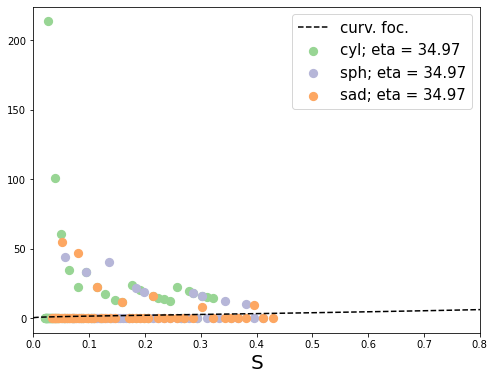

In [129]:
nmax = 59  # maximum stack size that counts as "self-limiting"

mask_a_0 = (nsla_a_0 <= nmax)
# mask_b_0 = (nsla_b_0 <= nmax)
# mask_c_0 = (nsla_c_0 <= nmax)
mask_b_0_0p25 = (nsla_b_0_0p25 <= nmax)
mask_c_0_0p25 = (nsla_c_0_0p25 <= nmax)
mask_e_0_0p25 = (nsla_e_0_0p25 <= nmax)


mask_a_45 = (nsla_a_45 <= nmax)
mask_b_45_0p25 = (nsla_b_45_0p25 <= nmax)
mask_c_45_0p25 = (nsla_c_45_0p25 <= nmax)
mask_d_45_0p25 = (nsla_d_45_0p25 <= nmax)
mask_e_45_0p25 = (nsla_e_45_0p25 <= nmax)

mask_a_m45 = (nsla_a_m45 <= nmax)
mask_b_m45_0p25 = (nsla_b_m45_0p25 <= nmax)
mask_c_m45_0p25 = (nsla_c_m45_0p25 <= nmax)
mask_d_m45_0p25 = (nsla_d_m45_0p25 <= nmax)
mask_e_m45_0p25 = (nsla_e_m45_0p25 <= nmax)


mask_c_m45 = (nsla_c_m45 <= nmax)


hc = np.linspace(0.01,10,100)
sc = sconformal(hc)

# fig, ax = plt.subplots(1,1,figsize = (6,8))
fig, ax = plt.subplots(1,1,figsize = (8,6))
ax.plot(sc,hc,"k--",label="curv. foc.")

### cylinders
# ax.plot(S_a_0[mask_a_0],H_a_0[mask_a_0],"-",color=cyl_colors[0])
# ax.scatter(S_a_0[mask_a_0],H_a_0[mask_a_0],edgecolor=cyl_colors[0],facecolor=cyl_colors[0],s=60,linewidths=1.5,label="cyl; eta = 0.099")
# ax.plot(S_b_0_0p25[mask_b_0_0p25],H_b_0_0p25[mask_b_0_0p25],"-",color=cyl_colors[1])
# ax.scatter(S_b_0_0p25[mask_b_0_0p25],H_b_0_0p25[mask_b_0_0p25],edgecolor=cyl_colors[1],facecolor=cyl_colors[1],s=60,linewidths=1.5,label="cyl; eta = 0.949")
# ax.plot(S_c_0_0p25[mask_c_0_0p25],H_c_0_0p25[mask_c_0_0p25],"-",color=cyl_colors[2])
# ax.scatter(S_c_0_0p25[mask_c_0_0p25],H_c_0_0p25[mask_c_0_0p25],edgecolor=cyl_colors[2],facecolor=cyl_colors[2],s=60,linewidths=1.5,label="cyl; eta = 8.744")

# ax.plot(S_e_0_0p25[mask_e_0_0p25][1:],np.diff(H_e_0_0p25[mask_e_0_0p25])/np.diff(S_e_0_0p25[mask_e_0_0p25]),"-",color=cyl_colors[4])
ax.scatter(S_e_0_0p25[mask_e_0_0p25][1:],np.diff(H_e_0_0p25[mask_e_0_0p25])/np.diff(S_e_0_0p25[mask_e_0_0p25]),edgecolor=cyl_colors[4],facecolor=cyl_colors[4],s=60,linewidths=1.5,label="cyl; eta = 34.97")


# ax.plot(S_b_0[mask_b_0],H_b_0[mask_b_0],"-",color=cyl_colors[1])
# ax.scatter(S_b_0[mask_b_0],H_b_0[mask_b_0],edgecolor=cyl_colors[1],facecolor=cyl_colors[1],s=60,linewidths=1.5,label="cyl; eta = 0.949")
# ax.plot(S_c_0[mask_c_0],H_c_0[mask_c_0],"-",color=cyl_colors[2])
# ax.scatter(S_c_0[mask_c_0],H_c_0[mask_c_0],edgecolor=cyl_colors[2],facecolor=cyl_colors[2],s=60,linewidths=1.5,label="cyl; eta = 8.744")


### spheres
# ax.plot(S_a_45[mask_a_45],H_a_45[mask_a_45],"-",color=sph_colors[0])
# ax.scatter(S_a_45[mask_a_45],H_a_45[mask_a_45],edgecolor=sph_colors[0],facecolor=sph_colors[0],s=60,linewidths=1.5,label="sph; eta = 0.099")
# ax.plot(S_b_45_0p25[mask_b_45_0p25],H_b_45_0p25[mask_b_45_0p25],"-",color=sph_colors[1])
# ax.scatter(S_b_45_0p25[mask_b_45_0p25],H_b_45_0p25[mask_b_45_0p25],edgecolor=sph_colors[1],facecolor=sph_colors[1],s=60,linewidths=1.5,label="sph; eta = 0.949")
# ax.plot(S_c_45_0p25[mask_c_45_0p25],H_c_45_0p25[mask_c_45_0p25],"-",color=sph_colors[2])
# ax.scatter(S_c_45_0p25[mask_c_45_0p25],H_c_45_0p25[mask_c_45_0p25],edgecolor=sph_colors[2],facecolor=sph_colors[2],s=60,linewidths=1.5,label="sph; eta = 8.744")
# ax.plot(S_d_45_0p25[mask_d_45_0p25],H_d_45_0p25[mask_d_45_0p25],"-",color=sph_colors[3])
# ax.scatter(S_d_45_0p25[mask_d_45_0p25],H_d_45_0p25[mask_d_45_0p25],edgecolor=sph_colors[3],facecolor=sph_colors[3],s=60,linewidths=1.5,label="sph; eta = 19.67")
# ax.plot(S_e_45_0p25[mask_e_45_0p25][1:],np.diff(H_e_45_0p25[mask_e_45_0p25])/np.diff(S_e_45_0p25[mask_e_45_0p25]),"-",color=sph_colors[4])
ax.scatter(S_e_45_0p25[mask_e_45_0p25][1:],np.diff(H_e_45_0p25[mask_e_45_0p25])/np.diff(S_e_45_0p25[mask_e_45_0p25]),edgecolor=sph_colors[4],facecolor=sph_colors[4],s=60,linewidths=1.5,label="sph; eta = 34.97")


### saddles
# ax.plot(S_a_m45[mask_a_m45],H_a_m45[mask_a_m45],"-",color=sad_colors[0])
# ax.scatter(S_a_m45[mask_a_m45],H_a_m45[mask_a_m45],edgecolor=sad_colors[0],facecolor=sad_colors[0],s=60,linewidths=1.5,label="sad; eta = 0.099")
# ax.plot(S_b_m45_0p25[mask_b_m45_0p25],H_b_m45_0p25[mask_b_m45_0p25],"-",color=sad_colors[1])
# ax.scatter(S_b_m45_0p25[mask_b_m45_0p25],H_b_m45_0p25[mask_b_m45_0p25],edgecolor=sad_colors[1],facecolor=sad_colors[1],s=60,linewidths=1.5,label="sad; eta = 0.949")
# ax.plot(S_c_m45_0p25[mask_c_m45_0p25],H_c_m45_0p25[mask_c_m45_0p25],"-",color=sad_colors[2])
# ax.scatter(S_c_m45_0p25[mask_c_m45_0p25],H_c_m45_0p25[mask_c_m45_0p25],edgecolor=sad_colors[2],facecolor=sad_colors[2],s=60,linewidths=1.5,label="sad; eta = 8.744")
# ax.plot(S_d_m45_0p25[mask_d_m45_0p25],H_d_m45_0p25[mask_d_m45_0p25],"-",color=sad_colors[3])
# ax.scatter(S_d_m45_0p25[mask_d_m45_0p25],H_d_m45_0p25[mask_d_m45_0p25],edgecolor=sad_colors[3],facecolor=sad_colors[3],s=60,linewidths=1.5,label="sad; eta = 19.67")
# ax.plot(S_e_m45_0p25[mask_e_m45_0p25][1:],np.diff(H_e_m45_0p25[mask_e_m45_0p25])/np.diff(S_e_m45_0p25[mask_e_m45_0p25]),"-",color=sad_colors[4])
ax.scatter(S_e_m45_0p25[mask_e_m45_0p25][1:],np.diff(H_e_m45_0p25[mask_e_m45_0p25])/np.diff(S_e_m45_0p25[mask_e_m45_0p25]),edgecolor=sad_colors[4],facecolor=sad_colors[4],s=60,linewidths=1.5,label="sad; eta = 34.97")


# ax.plot(S_c_m45[mask_c_m45],H_c_m45[mask_c_m45],"-",color=sad_colors[2])
# ax.scatter(S_c_m45[mask_c_m45],H_c_m45[mask_c_m45],edgecolor=sad_colors[2],facecolor=sad_colors[2],s=60,linewidths=1.5,label="sad; eta = 8.744")


# ax.set_ylabel("\frac{\Delta H}{\Delta S}",fontsize=20)
ax.set_xlabel("S",fontsize=20)
ax.legend(fontsize=15)
ax.set_xlim(0,0.8)
# ax.set_ylim(0,100)

# ax.set_xlim(0,0.2)
# ax.set_ylim(0,3)

# Size Fluctuations

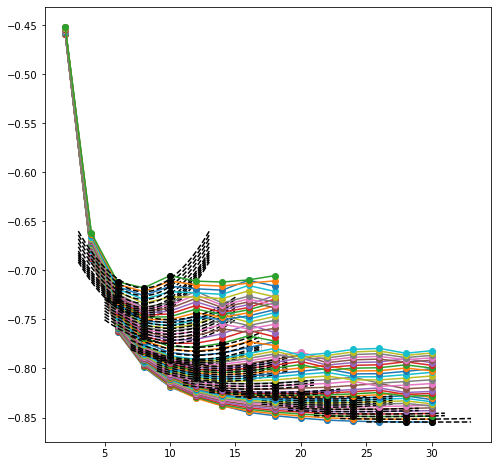

In [211]:
# sigma = 0.25 interactions

nmax = 59  # maximum stack size that counts as "self-limiting"

mask_a_0 = (nsla_a_0 <= nmax)
# mask_b_0 = (nsla_b_0 <= nmax)
# mask_c_0 = (nsla_c_0 <= nmax)
mask_b_0_0p25 = (nsla_b_0_0p25 <= nmax)
mask_c_0_0p25 = (nsla_c_0_0p25 <= nmax)
mask_e_0_0p25 = (nsla_e_0_0p25 <= nmax)


mask_a_45 = (nsla_a_45 <= nmax)
mask_b_45_0p25 = (nsla_b_45_0p25 <= nmax)
mask_c_45_0p25 = (nsla_c_45_0p25 <= nmax)
mask_d_45_0p25 = (nsla_d_45_0p25 <= nmax)
mask_e_45_0p25 = (nsla_e_45_0p25 <= nmax)

mask_a_m45 = (nsla_a_m45 <= nmax)
mask_b_m45_0p25 = (nsla_b_m45_0p25 <= nmax)
mask_c_m45_0p25 = (nsla_c_m45_0p25 <= nmax)
mask_d_m45_0p25 = (nsla_d_m45_0p25 <= nmax)
mask_e_m45_0p25 = (nsla_e_m45_0p25 <= nmax)


mask_c_m45 = (nsla_c_m45 <= nmax)

design = "d"
# alpha = 0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
alpha = 45 * np.pi/180
# alpha = -45 * np.pi/180

source = "txt" # "local" = on local machine; "txt" = from text files imported from remote machine
# source = "local"
txt_dir = f"{PROJECT_ROOT}/jobs/paper3D/energies"
# kh_list = "all"
nshells_list = np.arange(2,61,2)

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
sigma = 0.25*dcore

if design == "a":
    t0 = 4.434 * dcore    # structural thickness
    r0 = 54.053 * dcore   # RMS radius of curvature; set to "flat" for planar plates
    t = 5.408    # actual thickness (interaction minimum)
    tk0 = t/r0
    if alpha == 0 * np.pi/180:
        mask = mask_a_0
        kh_list = khsla_a_0[mask].tolist()
        nsla = nsla_a_0[mask].tolist()
    elif alpha == 45 * np.pi/180:
        mask = mask_a_45
        kh_list = khsla_a_45[mask].tolist()
        nsla = nsla_a_45[mask].tolist()
    elif alpha == -45 * np.pi/180:
        mask = mask_a_m45
        kh_list = khsla_a_m45[mask].tolist()
        nsla = nsla_a_m45[mask].tolist()

if design == "b":
    t0 = 2.35
    r0 = 32.893
    t = 3.324
    tk0 = t/r0
    if alpha == 0 * np.pi/180:
        mask = mask_b_0_0p25
        kh_list = khsla_b_0_0p25[mask].tolist()
        nsla = nsla_b_0_0p25[mask].tolist()
    elif alpha == 45 * np.pi/180:
        mask = mask_b_45_0p25
        kh_list = khsla_b_45_0p25[mask].tolist()
        nsla = nsla_b_45_0p25[mask].tolist()
    elif alpha == -45 * np.pi/180:
        mask = mask_b_m45_0p25
        kh_list = khsla_b_m45_0p25[mask].tolist()
        nsla = nsla_b_m45_0p25[mask].tolist()

if design == "c":
    t0 = 1.2
    r0 = 21.221
    t = 2.174
    tk0 = t/r0
    if alpha == 0 * np.pi/180:
        mask = mask_c_0_0p25
        kh_list = khsla_c_0_0p25[mask].tolist()
        nsla = nsla_c_0_0p25[mask].tolist()
    elif alpha == 45 * np.pi/180:
        mask = mask_c_45_0p25
        kh_list = khsla_c_45_0p25[mask].tolist()
        nsla = nsla_c_45_0p25[mask].tolist()
    elif alpha == -45 * np.pi/180:
        mask = mask_c_m45_0p25
        kh_list = khsla_c_m45_0p25[mask].tolist()
        nsla = nsla_c_m45_0p25[mask].tolist()
    
if design == "d":
    t0 = 0.8
    r0 = 21.221
    t = 1.774
    tk0 = t/r0
    if alpha == 0 * np.pi/180:
        mask = mask_d_0_0p25
        kh_list = khsla_d_0_0p25[mask].tolist()
        nsla = nsla_d_0_0p25[mask].tolist()
    elif alpha == 45 * np.pi/180:
        mask = mask_d_45_0p25
        kh_list = khsla_d_45_0p25[mask].tolist()
        nsla = nsla_d_45_0p25[mask].tolist()
    elif alpha == -45 * np.pi/180:
        mask = mask_d_m45_0p25
        kh_list = khsla_d_m45_0p25[mask].tolist()
        nsla = nsla_d_m45_0p25[mask].tolist()
    
if design == "e":
    t0 = 0.6
    r0 = 21.221
    t = 1.574
    tk0 = t/r0
    if alpha == 0 * np.pi/180:
        mask = mask_e_0_0p25
        kh_list = khsla_e_0_0p25[mask].tolist()
        nsla = nsla_e_0_0p25[mask].tolist()
    elif alpha == 45 * np.pi/180:
        mask = mask_e_45_0p25
        kh_list = khsla_e_45_0p25[mask].tolist()
        nsla = nsla_e_45_0p25[mask].tolist()
    elif alpha == -45 * np.pi/180:
        mask = mask_e_m45_0p25
        kh_list = khsla_e_m45_0p25[mask].tolist()
        nsla = nsla_e_m45_0p25[mask].tolist()

theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)
kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)


### Elasticity
# kh = kh_list[j]
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

### Interactions
pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
# epsilon = 0
shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
wcacut = dcore    # cutoff distance for repulsive wca potential
# softsigma = 5*sigma
# softepsilon = 5e-8 * epsilon
# softshift = 0 #softcore - 2**(1/6)*softsigma
# softcut = 2**(1/6) * softsigma

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
maxiter = 100000

parentdir = f"data/paper3D/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}" 

fig, ax = plt.subplots(1,1,figsize=(8,8))

epp_list = []
n_list = []

etotal_list = []
ebond_list = []
epair_list = []
nshells_good = []
stop_list = []
e2_list = []

if source == "local":
    
    
    if kh_list != "all": 
        khlist = kh_list
    else:
        result = ReadSim(f"{PROJECT_ROOT}/{parentdir}")
        files = result.files
        khlist = []
        for f in files:
            if f[:2] == "kh":
                khlist.append(float(f[3:]))        

    for i in np.arange(len(khlist)):
        kh = khlist[i]
        etotal_i = []
        ebond_i = []
        epair_i = []
        nshells_i = []
        stop_i = []
        e2_i = []
        for j in np.arange(len(nshells_list)):
            try:
                nshells = nshells_list[j]
#                     simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
                simpath = f"data/examples/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.2f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#                 simpath = f"{parentdir}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}" 
                logname = "log.lammps"
                result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                result.read_log(logname=logname)
                etotal_i.append(result.thermo_TotEng[-1])
                ebond_i.append(result.thermo_E_bond[-1])
                epair_i.append(result.thermo_E_pair[-1])
                nshells_i.append(nshells)
                stop_i.append(result.why_stop)
                e2_i.append(result.energy2)
            except:
                pass

        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
        stop_list.append(stop_i)
        e2_list.append(e2_i)
    
elif source == "txt":
    if kh_list != "all": 
        khlist = kh_list
    else:
        txts = ReadSim(txt_dir)
        files = txts.files
        files = fnmatch.filter(files, f"{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-*-{minstyle}-{int(np.abs(np.log10(etol)))}.txt")
        khlist = []
        for f in files:
            start_index = f.index("kh-") + len("kh-")
            end_index = f.index("-",start_index)
            kh = float(f[start_index:end_index])
            khlist.append(kh)
        khlist.sort()
    
    for i in np.arange(len(khlist)): #np.arange(3,11,1):
        kh = khlist[i]
        data = np.loadtxt(f"{txt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt",skiprows=1,usecols=(0,1,2,3,4))
        try: 
            nshells_i = data[:,0].tolist()
            etotal_i = data[:,1].tolist()
            ebond_i = data[:,2].tolist()
            epair_i = data[:,3].tolist()
            e2_i = data[:,4].tolist()
        except:
            nshells_i = [data[0]]
            etotal_i = [data[1]]
            ebond_i = [data[2]]
            epair_i = [data[3]]
            e2_i = [data[4]]
        
        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
#         stop_list.append(stop_i)
        e2_list.append(e2_i)
        
        imin = np.argmin((np.array(nshells_i)-nsla[i])**2)
        nnn = np.array(nshells_i)[imin-1:imin+2]
        enn = np.array(etotal_i)[imin-1:imin+2]/nnn
        
#         def harmonicfit(x,a,x0,y0):
#             return 0.5*a*(x-x0)**2 + y0

        def harmonicfit(x,a):
            return 0.5*a*(x-nnn[1])**2 + enn[1]
        
        params,cov = curve_fit(harmonicfit,nnn,enn)
        
        if params[0] <=0:
            print(f"Error: negative convexity detected for i = {i}; kh = {kh}")
            print(f"    check that nmin = {nnn[1]} is correct.")
        else:
            epp_list.append(params[0])
            n_list.append(nnn[1])
        x = np.linspace(nnn[0]-3,nnn[-1]+3,100)
        ax.plot(np.array(nshells_i),np.array(etotal_i)/np.array(nshells_i),"o-")
        ax.plot(nnn,enn,"ko")
        ax.plot(x,harmonicfit(x,*params),"k--")
        
# ax.set_ylim(-0.855,-0.835)

(0.05, 0.35)

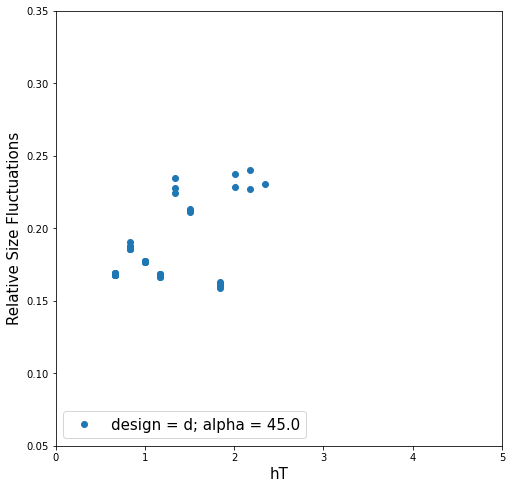

In [213]:
beta = 15

fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(np.array(n_list)*tk0,np.array(n_list)**(-3/2) * (beta * np.array(epp_list))**(-1/2),"o",label=f"design = {design}; alpha = {alpha*180/np.pi:0.1f}")

# xplot = np.array(n_list)*tk0
# yplot = np.array(n_list)**(-3/2) * (beta * np.array(epp_list))**(-1/2)
# ax.plot(xplot,yplot,"o")

ax.set_ylabel("Relative Size Fluctuations",fontsize=15)
ax.legend(fontsize=15)
# ax.set_xlabel("nT",fontsize=15)
# ax.set_xlim(0,31)
ax.set_xlabel("hT",fontsize=15)
ax.set_xlim(0,5)
ax.set_ylim(0.05,0.35)

In [214]:
print(f"nsla = np.array({n_list})\n")
print(f"hsla = np.array({(np.array(n_list) * tk0).tolist()})\n")
np.set_printoptions(suppress=True, precision=10)
print(
    "epp = np.array(["
    + ", ".join(f"{x:.10f}" for x in epp_list)
    + "])"
)

nsla = np.array([30.0, 28.0, 26.0, 26.0, 24.0, 24.0, 22.0, 22.0, 22.0, 22.0, 22.0, 20.0, 18.0, 18.0, 18.0, 16.0, 16.0, 16.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0])

hsla = np.array([2.5078931247349323, 2.3407002497526035, 2.1735073747702747, 2.1735073747702747, 2.006314499787946, 2.006314499787946, 1.839121624805617, 1.839121624805617, 1.839121624805617, 1.839121624805617, 1.839121624805617, 1.6719287498232882, 1.5047358748409594, 1.5047358748409594, 1.5047358748409594, 1.3375429998586306, 1.3375429998586306, 1.3375429998586306, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.1703501248763017, 1.003157249893973, 1.003157249893973, 1.003157249893973, 1.003157249893973, 1.003157249893973, 1.003157249893973, 1.003157249893973, 0.835964374

/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/homebrew/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covarian

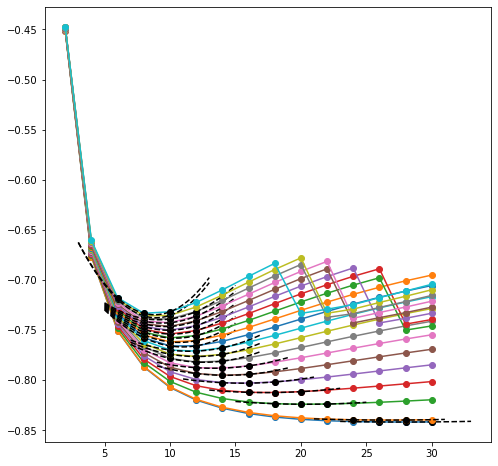

In [214]:
### Previous - different interactions

nmax = 29

mask_a_0 = (nsla_a_0 <= nmax)
mask_b_0 = (nsla_b_0 <= nmax)
mask_c_0 = (nsla_c_0 <= nmax)

mask_a_45 = (nsla_a_45 <= nmax)
mask_b_45 = (nsla_b_45 <= nmax)
mask_c_45 = (nsla_c_45 <= nmax)

mask_a_m45 = (nsla_a_m45 <= nmax)

mask_c_m45 = (nsla_c_m45 <= nmax)

design = "c0"
alpha = 0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
# alpha = 45 * np.pi/180
# alpha = -45 * np.pi/180
kh_list = khsla_c_0[mask_c_0].tolist()
nsla = nsla_c_0[mask_c_0].tolist()

def harmonicfit(x,a,x0,y0):
    return a*(x-x0)**2 + y0

source = "txt" # "local" = on local machine; "txt" = from text files imported from remote machine
# source = "local"
txt_dir = f"{PROJECT_ROOT}/jobs/paper3D/energies"
# kh_list = "all"
nshells_list = np.arange(2,31,2)

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell

if design == "a0":
    sigma = 0.25*dcore
    t0 = 4.434 * dcore    # structural thickness
    r0 = 54.053 * dcore   # RMS radius of curvature; set to "flat" for planar plates 

if design == "b0":
    sigma = 0.4108*dcore
    t0 = 2.35 * dcore    
    r0 = 32.893 * dcore

if design == "c0":
    sigma = 0.6368*dcore
    t0 = 1.2 * dcore    
    r0 = 21.221 * dcore  

theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)
kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)


### Elasticity
# kh = kh_list[j]
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

### Interactions
pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
# epsilon = 0
shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
wcacut = dcore    # cutoff distance for repulsive wca potential
# softsigma = 5*sigma
# softepsilon = 5e-8 * epsilon
# softshift = 0 #softcore - 2**(1/6)*softsigma
# softcut = 2**(1/6) * softsigma

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
maxiter = 100000

parentdir = f"data/paper3D/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}" 

fig, ax = plt.subplots(1,1,figsize=(8,8))

epp_list = []

etotal_list = []
ebond_list = []
epair_list = []
nshells_good = []
stop_list = []
e2_list = []

if source == "local":
    
    
    if kh_list != "all": 
        khlist = kh_list
    else:
        result = ReadSim(f"{PROJECT_ROOT}/{parentdir}")
        files = result.files
        khlist = []
        for f in files:
            if f[:2] == "kh":
                khlist.append(float(f[3:]))        

    for i in np.arange(len(khlist)):
        kh = khlist[i]
        etotal_i = []
        ebond_i = []
        epair_i = []
        nshells_i = []
        stop_i = []
        e2_i = []
        for j in np.arange(len(nshells_list)):
            try:
                nshells = nshells_list[j]
#                     simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
                simpath = f"data/examples/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.2f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#                 simpath = f"{parentdir}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}" 
                logname = "log.lammps"
                result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                result.read_log(logname=logname)
                etotal_i.append(result.thermo_TotEng[-1])
                ebond_i.append(result.thermo_E_bond[-1])
                epair_i.append(result.thermo_E_pair[-1])
                nshells_i.append(nshells)
                stop_i.append(result.why_stop)
                e2_i.append(result.energy2)
            except:
                pass

        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
        stop_list.append(stop_i)
        e2_list.append(e2_i)
    
elif source == "txt":
    if kh_list != "all": 
        khlist = kh_list
    else:
        txts = ReadSim(txt_dir)
        files = txts.files
        files = fnmatch.filter(files, f"{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-*-{minstyle}-{int(np.abs(np.log10(etol)))}.txt")
        khlist = []
        for f in files:
            start_index = f.index("kh-") + len("kh-")
            end_index = f.index("-",start_index)
            kh = float(f[start_index:end_index])
            khlist.append(kh)
        khlist.sort()
    
    for i in np.arange(len(khlist)):
        kh = khlist[i]
        data = np.loadtxt(f"{txt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt",skiprows=1,usecols=(0,1,2,3,4))
        try: 
            nshells_i = data[:,0].tolist()
            etotal_i = data[:,1].tolist()
            ebond_i = data[:,2].tolist()
            epair_i = data[:,3].tolist()
            e2_i = data[:,4].tolist()
        except:
            nshells_i = [data[0]]
            etotal_i = [data[1]]
            ebond_i = [data[2]]
            epair_i = [data[3]]
            e2_i = [data[4]]
        
        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
#         stop_list.append(stop_i)
        e2_list.append(e2_i)
        
        imin = np.argmin((np.array(nshells_i)-nsla[i])**2)
        nnn = np.array(nshells_i)[imin-1:imin+2]
        enn = np.array(etotal_i)[imin-1:imin+2]/nnn
        
        params,cov = curve_fit(harmonicfit,nnn,enn)
        epp_list.append(params[0])
        x = np.linspace(nnn[0]-3,nnn[-1]+3,100)
        ax.plot(np.array(nshells_i),np.array(etotal_i)/np.array(nshells_i),"o-")
        ax.plot(nnn,enn,"ko")
        ax.plot(x,harmonicfit(x,*params),"k--")
        
# ax.set_ylim(-0.85,-0.8)

In [215]:
print(f"nsla = np.array({nsla})")
print(f"epp = np.array({epp_list})")

nsla = np.array([28.0, 26.0, 20.0, 18.0, 16.0, 14.0, 14.0, 12.0, 12.0, 12.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0])
epp = np.array([2.6329975704020696e-05, 3.616927569971551e-05, 9.46173654519918e-05, 0.00013394611454542918, 0.00020526552911904108, 0.00033381182001343367, 0.0003250007953458736, 0.0005659418633696816, 0.0005597476265833081, 0.0005521412951895205, 0.0010359746027511522, 0.0010336733726643886, 0.0010300807884382804, 0.0010252698841141906, 0.0010192905503921912, 0.001012197692278331, 0.0010040287428160894, 0.00099482085028525, 0.0021257237418691004, 0.002125650442765052])


(0.0, 0.7)

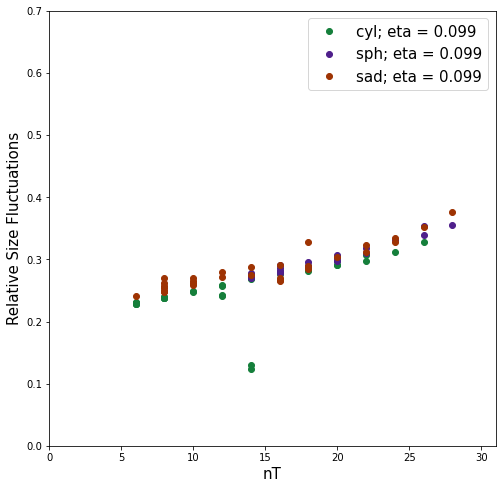

In [221]:
nT_a_0 = np.array([26.0, 24.0, 22.0, 22.0, 20.0, 20.0, 20.0, 18.0, 18.0, 18.0, 16.0, 16.0, 14.0, 14.0, 14.0, 14.0, 12.0, 12.0, 12.0, 12.0, 10.0, 10.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0])
epp_a_0 = np.array([3.539587071500422e-05, 4.934560708672377e-05, 7.060320862387017e-05, 6.630900642681204e-05, 9.848003682998811e-05, 9.790849869436415e-05, 9.37402581439731e-05, 0.00014434138524068856, 0.00014057379732113504, 0.0001363939547491922, 0.0002121573317542079, 0.0002054950718387459, 0.0003361536558305498, 0.0003329850758733157, 0.0014208323288809612, 0.0015739835621742485, 0.0006615397165442121, 0.0005819519947303166, 0.0006529319797084465, 0.000575562964556552, 0.0010854909986799588, 0.0010784804048030098, 0.0022685256845040203, 0.0022823900772668292, 0.0022909961554208958, 0.0022946777313926255, 0.002292764863477744, 0.002285380987197369, 0.0022728601842787635, 0.005797833677019198, 0.005824796466922642, 0.005848108232766827, 0.005869737590298622, 0.005886476438463993, 0.005899623726099115, 0.0059086888184769265]) 
nT_a_45 = np.array([28.0, 26.0, 26.0, 24.0, 22.0, 22.0, 20.0, 20.0, 20.0, 18.0, 18.0, 16.0, 16.0, 16.0, 16.0, 14.0, 14.0, 14.0, 14.0])
epp_a_45 = np.array([2.4096326234729458e-05, 3.3042190373626687e-05, 3.026659925924506e-05, 4.381503945571481e-05, 6.47265242191367e-05, 6.184007730095464e-05, 9.43496253683727e-05, 9.155083494411941e-05, 8.85990132687872e-05, 0.00013703228474782218, 0.000131149300585742, 0.00021115189657663124, 0.00020549412373569665, 0.0001994707473893328, 0.00019302998446922077, 0.0003311538680758576, 0.0003257021116761939, 0.0003199179773843342, 0.00031377530816926487])
nT_a_m45 = np.array([28.0, 26.0, 24.0, 24.0, 22.0, 22.0, 20.0, 18.0, 18.0, 18.0, 16.0, 16.0, 16.0, 16.0, 14.0, 14.0, 12.0, 12.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 6.0])
epp_a_m45 = np.array([2.143498167389877e-05, 3.0507116802463698e-05, 4.482230147642325e-05, 4.2909793698189046e-05, 6.422020819148047e-05, 5.9781279470452804e-05, 9.02474041488802e-05, 0.0001409885781528653, 0.00013664107514149208, 0.00010611447659547762, 0.0002316614292552062, 0.000227152920848982, 0.00022227793367931932, 0.00019140264650317385, 0.0003208680281671807, 0.0002924863791574925, 0.0005198322158882419, 0.0004949998455345551, 0.0009931520489565677, 0.0009725279810952142, 0.0009471182488679802, 0.0009167153093337806, 0.0021237436554676597, 0.0021073888395732048, 0.0020873860950803877, 0.002030987500203047, 0.001965130530884202, 0.0018863144441798904, 0.0017949884772455898, 0.0052774371955751735])

nT_c_0 = np.array([28.0, 26.0, 20.0, 18.0, 16.0, 14.0, 14.0, 12.0, 12.0, 12.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0])
epp_c_0 = np.array([2.6329975704020696e-05, 3.616927569971551e-05, 9.46173654519918e-05, 0.00013394611454542918, 0.00020526552911904108, 0.00033381182001343367, 0.0003250007953458736, 0.0005659418633696816, 0.0005597476265833081, 0.0005521412951895205, 0.0010359746027511522, 0.0010336733726643886, 0.0010300807884382804, 0.0010252698841141906, 0.0010192905503921912, 0.001012197692278331, 0.0010040287428160894, 0.00099482085028525, 0.0021257237418691004, 0.002125650442765052])
nT_c_45 = np.array([26.0, 24.0, 22.0, 20.0, 20.0, 18.0, 18.0, 18.0, 18.0, 16.0, 16.0, 16.0, 14.0])
epp_c_45 = np.array([1.364408607345709e-05, 1.9415551847522214e-05, 2.977864829446176e-05, 4.841650614503301e-05, 4.2751799111890745e-05, 7.524523844152725e-05, 6.872575329279174e-05, 6.255690723607652e-05, 5.674298529284827e-05, 0.00011257660098227154, 0.00010547865699951457, 9.868361120738024e-05, 0.0001722823802145839])
nT_c_m45 = np.array([28.0, 26.0, 26.0, 24.0, 24.0, 22.0, 22.0, 22.0, 20.0, 20.0, 20.0, 18.0, 18.0, 18.0, 18.0, 16.0, 16.0, 16.0, 16.0, 14.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0, 8.0, 8.0])
epp_c_m45 = np.array([2.750401480866522e-05, 3.673836991677164e-05, 3.4925891629746945e-05, 5.0758196680297466e-05, 4.901549641504731e-05, 7.289104714782044e-05, 7.132816035074072e-05, 6.968623279573875e-05, 0.00010585418075080257, 0.00010303001909308575, 9.997278507220279e-05, 0.00015440069940714053, 0.00015178724872349554, 0.00014893247363032675, 0.00014585773791436803, 0.00023261250185362717, 0.0002302640378628989, 0.0002276988028893361, 0.00022492423779373004, 0.0003581171062067917, 0.0005965951620088998, 0.00058827668848939, 0.0005763920708851131, 0.000561445760957006, 0.0005438656007618242, 0.000524036900079786, 0.0010228651032607335, 0.0010091747402646476, 0.0009934996339098442, 0.0009567302756220828, 0.0009139595355395563, 0.0008663799507792217, 0.0008150888478576489, 0.0019776414411741064, 0.0019404519089516541, 0.0018993022218741864, 0.001854643858790983])

beta = 15

fig, ax = plt.subplots(1,1,figsize=(8,8))
# cylinders
ax.plot(nT_a_0,nT_a_0**(-3/2) * (beta * epp_a_0)**(-1/2),"o",color=cyl_colors[0],label="cyl; eta = 0.099")
# ax.plot(nT_c_0,nT_c_0**(-3/2) * (beta * epp_c_0)**(-1/2),"o",color=cyl_colors[2],label="cyl; eta = 8.744")


# spheres
ax.plot(nT_a_45,nT_a_45**(-3/2) * (beta * epp_a_45)**(-1/2),"o",color=sph_colors[0],label="sph; eta = 0.099")
# ax.plot(nT_c_45,nT_c_45**(-3/2) * (beta * epp_c_45)**(-1/2),"o",color=sph_colors[2],label="sph; eta = 8.744")


# saddles
ax.plot(nT_a_m45,nT_a_m45**(-3/2) * (beta * epp_a_m45)**(-1/2),"o",color=sad_colors[0],label="sad; eta = 0.099")
# ax.plot(nT_c_m45,nT_c_m45**(-3/2) * (beta * epp_c_m45)**(-1/2),"o",color=sad_colors[2],label="sad; eta = 8.744")


ax.set_xlabel("nT",fontsize=15)
ax.set_ylabel("Relative Size Fluctuations",fontsize=15)
ax.legend(fontsize=15)
ax.set_xlim(0,31)
ax.set_ylim(0,0.7)